# SDSS Galaxy Sample Processing


Este cuaderno detalla el procedimiento de carga, fusión, limpieza y cálculo de propiedades físicas de una muestra de galaxias obtenidas del Sloan Digital Sky Survey (SDSS).

El flujo de trabajo consiste en:

Configuración del entorno: Definición de cosmología y rutas de archivos.

Carga de datos: Lectura de catálogos espectroscópicos (MPA-JHU) y fotométricos (CasJobs).

Fusión de catálogos: Unión basada en el identificador único SPECOBJID.

Preprocesamiento: Corrección por extinción galáctica y cortes de calidad.

Cálculos derivados: Obtención de distancias de luminosidad y magnitudes absolutas.

Máscara para galaxias con formación estelar

In [55]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib as mpl
import matplotlib.gridspec as gridspec
from astropy.io import fits
from astropy.table import Table
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u
from scipy import stats
import warnings
from functools import reduce # Para unir tablas de forma eficiente

from calc_kcor_and_slope import get_kcor_and_slope
from itables import init_notebook_mode, show


In [56]:
# Definición del modelo cosmológico (H0=70, Om0=0.3)
cosmo = FlatLambdaCDM(H0=70, Om0=0.3)

# Parámetros de filtrado
Z_MIN = 0.001 # Corte mínimo de redshift para evitar estrellas o errores

# Configuración de rutas (Rutas relativas para portabilidad)
BASE_DIR = os.getcwd()
DATA_FOLDER = os.path.join(BASE_DIR, "datos")
PHOTOMETRY_FILE = "datos_finales_v4_lauramedina.csv"
FITS_FILES = [
    "galSpecInfo-dr8.fits",
    "galSpecLine-dr8.fits",
    "galSpecIndx-dr8.fits",
    "galSpecExtra-dr8.fits"
]

print(f"Modelo Cosmológico: {cosmo}")
print(f"Directorio de datos configurado: {DATA_FOLDER}")

Modelo Cosmológico: FlatLambdaCDM(H0=70.0 km / (Mpc s), Om0=0.3, Tcmb0=0.0 K, Neff=3.04, m_nu=None, Ob0=0.0)
Directorio de datos configurado: /Users/lauramedinacrespo/Documents/TFM/CODE/datos


## Configuración gráfica global

Bloque único de estilo, paleta de colores y tamaños de figura para todo el TFM.

In [57]:
# Estilo base 
plt.style.use('seaborn-v0_8-paper')
sns.set_theme(style='whitegrid', font='serif')

# Parámetros globales
plt.rcParams.update({
    'font.family':       'serif',
    'font.size':          11,
    'axes.titlesize':     12,
    'axes.titleweight':  'bold',
    'axes.labelsize':     12,
    'xtick.labelsize':    12,
    'ytick.labelsize':    12,
    'legend.fontsize':    12,
    'figure.dpi':         150,
    'figure.figsize':    (8, 6),
    'figure.autolayout':  True,
    'axes.grid':          True,
    'grid.alpha':          0.3,
    'grid.linestyle':     '--',
    'savefig.dpi':        150,
    'savefig.bbox':      'tight',
})

# Paleta de colores del TFM 
TFM_COLORS = {
    'muestra_total': 'lightsteelblue', # azul
    'submuestra':    '#E8A838', # dorado 
    'fondo':         '#AAAAAA', # gris neutro 
    'corte':         '#D62728', # rojo (lineas axvline)
    'snr_estricto':  '#5B9BD5', # azul   S/N > 5
    'snr_dudoso':    'rosybrown', # violeta  3 < S/N <= 5
    'con_oiii':      'dodgerblue', # verde  con [OIII]
    'sin_oiii':      'silver',   # gris   sin [OIII]
}

# Tamaños estándar de figura
TFM_FIG = {
    'simple':   (8,  6),
    'apaisado': (10, 5),
    'doble':    (14, 6),
    'cuadro':   (14, 10),
    'bpt':      (10, 8),
    'tira':     (16, 7),
}

print("Configuración gráfica del TFM cargada.")
print(f"  Colores: {list(TFM_COLORS.keys())}")
print(f"  Tamaños: {list(TFM_FIG.keys())}")


Configuración gráfica del TFM cargada.
  Colores: ['muestra_total', 'submuestra', 'fondo', 'corte', 'snr_estricto', 'snr_dudoso', 'con_oiii', 'sin_oiii']
  Tamaños: ['simple', 'apaisado', 'doble', 'cuadro', 'bpt', 'tira']


## 1. Definición de funciones de carga y procesamiento

cargar los archivos de espectroscopía (MPA-JHU) y el CSV con la fotometría descargada de CasJobs. Es crucial que los unamos usando el identificador único (SPECOBJID).

Para garantizar la reproducibilidad y modularidad del código, se definen funciones específicas para la ingesta de datos FITS y CSV. Se implementa una estrategia de fusión (merge) basada estrictamente en el identificador SPECOBJID para asegurar la integridad de los datos cruzados entre las distintas tablas del catálogo MPA-JHU y la fotometría.

Se definen funciones robustas para la ingesta de datos que resuelven tres problemas críticos:

1. Desglose vectorial: Expande columnas multidimensionales (arrays) de los FITS.

2. Unicidad de ID: Elimina duplicados en cada archivo antes de fusionar.

3. Limpieza de Metadatos: Durante la fusión, se descartan automáticamente las columnas redundantes (como PLATEID, MJD, RA, DEC) que aparecen repetidas en múltiples archivos, evitando errores de duplicidad en Pandas.


In [58]:
def load_fits_table_robust(filepath, columns=None):
    """
    Carga FITS, expande arrays y asegura unicidad del ID.
    """
    try:
        with fits.open(filepath) as hdul:
            tbl = Table(hdul[1].data)
        
        # 1. EXPANSIÓN DE ARRAYS 
        multidim_cols = [name for name in tbl.colnames if len(tbl[name].shape) > 1]
        
        if multidim_cols:
            # print(f"   ...Desempaquetando: {multidim_cols}") # Comentado para limpiar output
            pass
            
        for col in multidim_cols:
            data = tbl[col]
            n_subcols = data.shape[1]
            for i in range(n_subcols):
                tbl[f"{col}_{i}"] = data[:, i]
            del tbl[col]

        df = tbl.to_pandas()
        
        # 2. UNICIDAD
        if 'SPECOBJID' in df.columns:
            df['SPECOBJID'] = pd.to_numeric(df['SPECOBJID'], errors='coerce').astype('Int64')
            
            # Eliminación preventiva de duplicados en el origen
            df = df.drop_duplicates(subset=['SPECOBJID'], keep='first')
        
        # Filtrado opcional de columnas
        if columns:
            cols_to_keep = list(set(columns + ['SPECOBJID']))
            cols_existentes = [c for c in cols_to_keep if c in df.columns]
            df = df[cols_existentes]
            
        return df

    except Exception as e:
        print(f"Error al cargar {filepath}: {e}")
        return None

def load_photometry_csv(filepath):
    """
    Carga CSV fotometría con limpieza de duplicados.
    """
    try:
        df = pd.read_csv(filepath)
    except pd.errors.ParserError:
        print("Aviso: CSV con separador ';'.")
        df = pd.read_csv(filepath, sep=';')

    df.columns = df.columns.str.strip()
    id_map = {c: 'SPECOBJID' for c in df.columns if c.lower() == 'specobjid'}
    
    if id_map:
        df.rename(columns=id_map, inplace=True)
        df['SPECOBJID'] = pd.to_numeric(df['SPECOBJID'], errors='coerce').astype('Int64')
        df = df.dropna(subset=['SPECOBJID'])
        # Limpieza de duplicados en CSV
        df = df.drop_duplicates(subset=['SPECOBJID'], keep='first')
        return df
    else:
        raise KeyError("Falta columna SPECOBJID en CSV")

def clean_merge(left, right):
    """
    Función auxiliar para unir tablas evitando columnas duplicadas.
    Si una columna ya existe en la tabla 'left' (maestra), se borra de la 'right'
    antes de unir, para evitar sufijos (_x, _y) y errores de colisión.
    """
    # Identificar columnas repetidas (que no sean la clave de unión)
    cols_in_both = [c for c in right.columns if c in left.columns and c != 'SPECOBJID']
    
    # Eliminar las repetidas de la tabla entrante (right)
    if cols_in_both:
        right_clean = right.drop(columns=cols_in_both)
    else:
        right_clean = right
        
    # Unir
    return pd.merge(left, right_clean, on='SPECOBJID', how='inner')

def build_master_catalog(folder, fits_list, photo_file):
    """
    Orquesta la carga y fusión limpia.
    """
    data_frames = []
    
    # 1. Carga FITS
    print("1. Cargando archivos FITS ")
    for fname in fits_list:
        path = os.path.join(folder, fname)
        if os.path.exists(path):
            df_temp = load_fits_table_robust(path)
            if df_temp is not None:
                data_frames.append(df_temp)
                print(f"-> {fname} ({len(df_temp)} registros)")
            else:
                return None
        else:
            print(f"PELIGRO: Falta archivo {fname}")
            return None

    # 2. Carga Fotometría
    print(f"2. Cargando Fotometría")
    path_photo = os.path.join(folder, photo_file)
    if os.path.exists(path_photo):
        df_photo = load_photometry_csv(path_photo)
        data_frames.append(df_photo)
        print(f"-> CSV ({len(df_photo)} registros)")
    else:
        return None
    
    # 3. Fusión
    print(f"3. Fusionando tablas (Inner Join Limpio)")
    try:
        # Se usa clean_merge en lugar de pd.merge directo
        df_final = reduce(clean_merge, data_frames)
        return df_final
    except Exception as e:
        print(f"Error detallado durante la fusión: {e}")
        return None

## 2. Generación del catálogo maestro y limpieza inicial
   
Se ejecuta la función de carga consolidada. Posteriormente, se realiza una limpieza preliminar eliminando objetos con redshift (Z) nulo o negativo, los cuales suelen corresponder a estrellas o errores instrumentales que contaminarían el análisis galáctico.

In [59]:
# Generación del DataFrame principal
df = build_master_catalog(DATA_FOLDER, FITS_FILES, PHOTOMETRY_FILE)

if df is not None:
    n_total = len(df)
    print(f"\nTotal de objetos coincidentes en todas las tablas: {n_total}")

    # Limpieza por Redshift
    # Se eliminan objetos con Z <= Z_MIN (definido en config)
    df = df[df['Z'] > Z_MIN].copy()
    n_clean = len(df)
    
    print(f"Objetos tras corte de redshift (Z > {Z_MIN}): {n_clean}")
    print(f"Objetos descartados: {n_total - n_clean}")
    
    # Reinicio del índice para asegurar alineación
    df.reset_index(drop=True, inplace=True)
else:
    print("Error: no se pudo generar el catálogo.")

1. Cargando archivos FITS 
-> galSpecInfo-dr8.fits (1472582 registros)
-> galSpecLine-dr8.fits (1472582 registros)
-> galSpecIndx-dr8.fits (1472582 registros)
-> galSpecExtra-dr8.fits (1472582 registros)
2. Cargando Fotometría
-> CSV (854227 registros)
3. Fusionando tablas (Inner Join Limpio)

Total de objetos coincidentes en todas las tablas: 719518
Objetos tras corte de redshift (Z > 0.001): 718719
Objetos descartados: 799


Con el código siguiente se guarda el catálogo fusionado sin máscaras ni filtrados reales.
```
# CHECKPOINT (PICKLE)
# Se usa .pkl en lugar de .csv para guardar
# DATA_FOLDER es la variable que se define al principio (datos/)
checkpoint_filename = "SDSS_Master_RAW_CHECKPOINT.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

print(f"Intentando guardar checkpoint rápido en: {checkpoint_filename}...")

try:
    # to_pickle vuelca la memoria al disco 
    df.to_pickle(checkpoint_path)
    
    file_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"Guardado")
    print(f"Tamaño: {file_size_mb:.2f} MB")
except Exception as e:
    print(f"Error: {e}")
```

En lugar de reiniciar kernel puede usarse esto para modificar los datos.

```
# CARGA RÁPIDA (PICKLE)
checkpoint_filename = "SDSS_Master_RAW_CHECKPOINT.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

if os.path.exists(checkpoint_path):
    print("Cargando desde Pickle...")
    df = pd.read_pickle(checkpoint_path)
    print(f"-> Cargadas {len(df)} galaxias.")
else:
    print("No existe el checkpoint.")
```

Es importante señalar que la tabla de fotometría es bastante más corta porque al realizar el query imponemos el filtro RELIABLE=1, es decir, que los datos no tengan fallos.

## 3. Filtros iniciales de calidad
Se calcula la relación Señal/Ruido (S/N) de la línea H-beta y se aplica el primer filtro de calidad: datos fiables (RELIABLE=1) y sin advertencias en el cálculo del redshift (Z_WARNING=0).

Además se verifica que todos los objetos son galaxias. Se busca que columnas de clasificación del catálogo nos dan información sobre los objetos observados. 

In [60]:
cols_tipo = [c for c in df.columns if 'class' in c.lower() or 'type' in c.lower()]
print(f"Posibles columnas de clasificación: {cols_tipo}")

for col in cols_tipo:
    print(f"\nValores únicos en '{col}':")
    print(df[col].unique())
    if len(df) > 0:
        ejemplo = df[col].iloc[0]
        print(f"Tipo de dato: {type(ejemplo)}") 

Posibles columnas de clasificación: ['TARGETTYPE', 'SPECTROTYPE', 'SUBCLASS', 'BPTCLASS']

Valores únicos en 'TARGETTYPE':
<StringArray>
['GALAXY             ', 'SERENDIPITY_DISTANT', 'QSO                ',
 'QA                 ', 'ROSAT_D            ', 'SERENDIPITY_FIRST  ',
 'STAR_CARBON        ', 'SERENDIPITY_MANUAL ', 'SERENDIPITY_BLUE   ',
 'STAR_BHB           ', 'STAR_WHITE_DWARF   ', 'STAR_PN            ',
 'REDDEN_STD         ', 'HOT_STD            ', 'STAR_SUB_DWARF     ',
 'STAR_BROWN_DWARF   ', 'STAR_RED_DWARF     ', 'STAR_CATY_VAR      ',
 'ROSAT_A            ', 'ROSAT_C            ', 'SPECTROPHOTO_STD   ',
 'ROSAT_B            ', 'SKY                ', 'SERENDIPITY_RED    ']
Length: 24, dtype: str
Tipo de dato: <class 'str'>

Valores únicos en 'SPECTROTYPE':
<StringArray>
['GALAXY']
Length: 1, dtype: str
Tipo de dato: <class 'str'>

Valores únicos en 'SUBCLASS':
<StringArray>
['STARFORMING          ', '                     ', 'BROADLINE            ',
 'STARBURST           

La columna BPTCLASS clasifica las galaxias basándose en su posición en el diagrama BPT (Baldwin-Phillips-Terlevich). Este diagnóstico es esencial para identificar el mecanismo físico responsable de la ionización del gas en la galaxia: formación estelar o un núcleo galáctico activo (AGN).

El catálogo asigna un número entero según la ubicación del espectro en el diagrama de diagnóstico:

| Valor | Clasificación | Descripción Física                                                   |
|-------|---------------|----------------------------------------------------------------------|
| 1     | Star Forming  | Galaxias con formación estelar dominante (Regiones HII).             |
| 2     | Composite     | Mezcla de formación estelar y actividad de AGN.                      |
| 3     | AGN (Seyfert) | Dominada por un AGN de alta excitación (agujero negro).              |
| 4     | LINER         | Low-Ionization Nuclear Emission-line Region. AGN de baja excitación. |
| 5     | Ambiguous     | Las líneas se detectan pero no hay consenso en la clasificación.     |
| -1    | Not Measured  | Señal-ruido insuficiente para realizar el diagnóstico.               |


La clasificación se basa en la relación de flujo de líneas de emisión específicas (razones de líneas). 

El diagrama principal compara:

Eje Y: $\log_{10}(\text{[O III]} \lambda 5007 / \text{H}\beta)$

Eje X: $\log_{10}(\text{[N II]} \lambda 6584 / \text{H}\alpha)$

Para separar estas clases, el equipo de MPA-JHU utiliza líneas divisorias matemáticas:

- Kauffmann et al. (2003): Una línea empírica que marca el límite superior de la secuencia de formación estelar pura. Todo lo que esté por debajo es Clase 1.

- Kewley et al. (2001): Una línea teórica que representa el límite máximo de ionización que pueden alcanzar las estrellas jóvenes. Lo que queda entre la línea de Kauffmann y Kewley es la zona Composite (Clase 2).

- Zona AGN: Todo lo que esté por encima de la línea de Kewley se considera un AGN, dividiéndose luego entre Seyferts (Clase 3) y LINERs (Clase 4).

Se observa aquí que aunque las razones de apuntado 'targettype' son diversas, todos los objetos son galaxias espectroscópicas ('spectrotype'). 

Antes de realizar el filtrado, se muestra un hizstograma del redshift:

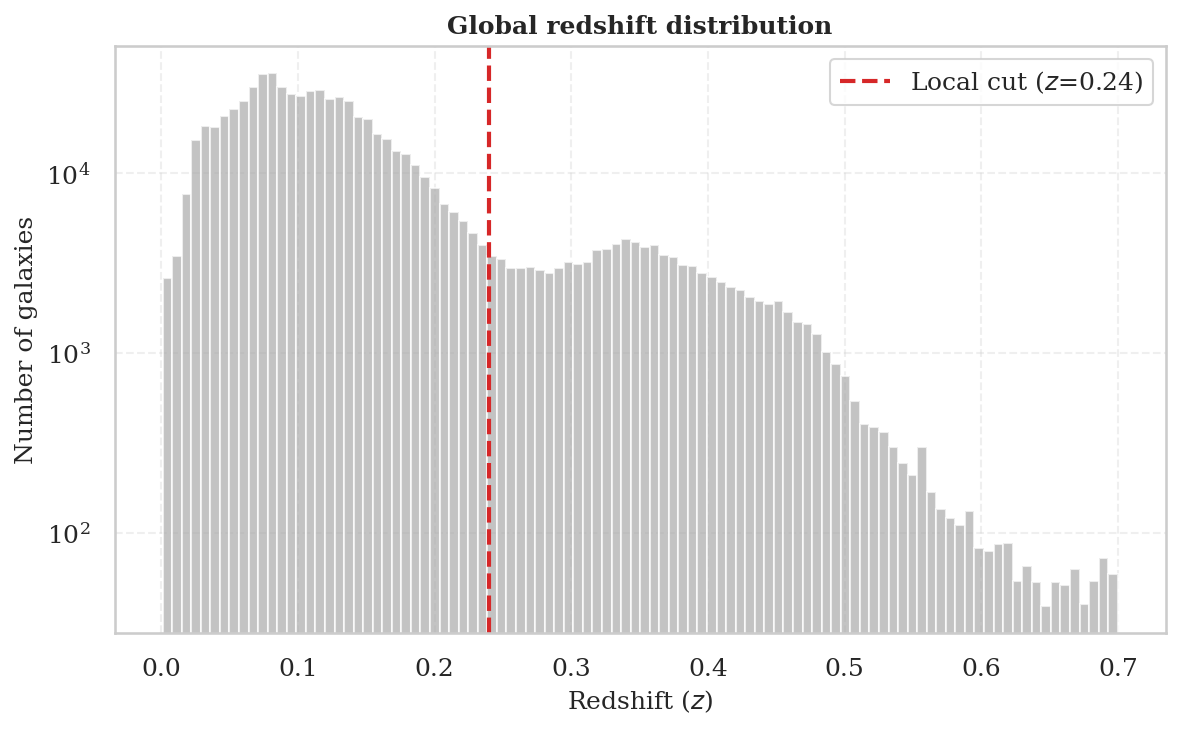

In [61]:
# Histograma de redshift
plt.figure(figsize=(8, 5))
plt.hist(df['Z'], bins=100, color=TFM_COLORS['fondo'], alpha=0.7, log=True)
plt.axvline(0.24, color=TFM_COLORS['corte'], linestyle='--', lw=2, label='Local cut ($z$=0.24)')
plt.title("Global redshift distribution")
plt.xlabel(f"Redshift ($z$)")
plt.ylabel("Number of galaxies")
plt.legend()
plt.grid(alpha=0.3)
plt.savefig('distr_redshift.png', dpi=300)
plt.show()

Se procede a hacer el filtrado de calidad.

Se añade el filtro en redshift < 0.6 para más tarde poder utilizar unas fórmulas de corrección K. Como se busca una muestra local, este corte no afecta al análisis.

Para garantizar la fiabilidad de las correcciones K y de la fotometría base, se aplica un filtro de calidad sobre las magnitudes aparentes del catálogo SDSS. 

Se restringe la muestra a galaxias con magnitudes observadas en el rango $12 < \text{modelMag} < 23$ en las bandas g y r. El límite débil ($m < 23$) se establece en concordancia con el límite fotométrico de completitud del 95% del SDSS ($r \approx 22.2$, York et al. 2000; Stoughton et al. 2002), por debajo del cual los errores fotométricos se disparan y los colores $g-r$ introducidos en los polinomios de corrección K (Chilingarian et al. 2010) carecen de sentido físico. El límite brillante ($m > 12$) se impone para descartar objetos espacialmente muy extensos o que saturan los sensores CCD del telescopio, lo que compromete la estimación del modelo de magnitud total (Lupton et al. 2001; Strauss et al. 2002).

In [62]:
# FILTROS DE CALIDAD

# 1. Calcular S/N de H-beta
# Se usa np.where para evitar división por cero
hb_flux = df.get('H_BETA_FLUX', df.get('HB_FLUX')) # Busca el nombre correcto
hb_err = df.get('H_BETA_FLUX_ERR', df.get('HB_FLUX_ERR'))

df['SN_HB'] = np.where(hb_err > 0, hb_flux / hb_err, 0) # Añadimos a la tabla

# 2. Aplicar Máscara Básica
print(f"Objetos antes del filtrado: {len(df)}")


# Máscara conjunta
mask_reliable = ((df['RELIABLE'] == 1) & (df['Z_WARNING'] == 0))

df = df[mask_reliable].reset_index(drop=True)

print(f"Galaxias 'Reliable' filtradas: {len(df)}")

# 3. Máscara fotométrica (eliminar los -9999 del SDSS) y límite de color
col_g = 'modelMag_g'
col_r = 'modelMag_r'

# Se calcula el color aparente
color_gr = df[col_g] - df[col_r]

mask_photo_strict = (
    # 1. Una magnitud física real para una galaxia en el SDSS siempre es > 0 y < 23
    (df[col_g] > 12) & (df[col_g] < 23) & 
    (df[col_r] > 12) & (df[col_r] < 23) &
    # 2. Colores físicos reales para galaxias (evita que la corrección K explote)
    (color_gr > -0.5) & (color_gr < 2.5) &
    # 3. Redshift válido para las fórmulas de Chilingarian -> más tarde la usaremos para la corrección K
    (df['Z'] > 0.001) & (df['Z'] < 0.6)
)

df = df[mask_photo_strict].reset_index(drop=True)
print(f"Galaxias con datos físicos reales: {len(df)}")

Objetos antes del filtrado: 718719
Galaxias 'Reliable' filtradas: 715475
Galaxias con datos físicos reales: 712582


## 4. Función auxiliar para gráficos

Se define la función de histograma con estadísticas.

In [63]:
def plot_histogram_stats(data, title, xlabel,
                         color=None, bins='auto',
                         xlim=None, save_path=None, log=True):
    """
    Histograma con media, mediana y cuartiles Q1/Q3.
    Parametros
    ----------
    data      : pd.Series
    title     : str
    xlabel    : str
    color     : str  — usa TFM_COLORS['...'] (default: muestra_total)
    bins      : int o 'auto'
    xlim      : tupla (min, max) opcional
    save_path : str opcional -> guarda la figura en disco
    """
    if log is True:
      log_elect=True
    else:
      log_elect=False
      
    if color is None:
        color = TFM_COLORS['muestra_total']

    fig, ax = plt.subplots(figsize=TFM_FIG['simple'])

    mu  = data.mean()
    med = data.median()
    q1  = data.quantile(0.25)
    q3  = data.quantile(0.75)

    ax.hist(data, bins=bins, color=color,
            histtype='bar',
            alpha=0.7,
            edgecolor='white',
            linewidth=0.5,
            log=log_elect,
            label='Distribution')

    ax.axvline(mu,  color=TFM_COLORS['corte'], lw=2, label=f'Mean = {mu:.2f}')
    ax.axvline(med, color='forestgreen', lw=2, ls='--', label=f'Median = {med:.2f}')
    ax.axvline(q1,  color='navy', lw=1.5, ls=':', label=f'Q1 = {q1:.2f}')
    ax.axvline(q3,  color='navy', lw=1.5, ls=':', label=f'Q3 = {q3:.2f}')

    ax.set_title(title)
    ax.set_xlabel(xlabel)
    ax.set_ylabel('Number of objects')
    if xlim:
        ax.set_xlim(xlim)
    ax.legend()

    if save_path:
        fig.savefig(save_path, dpi=300)
        print(f"Figura guardada en: {save_path}")
    plt.show()

## 5. Corrección de extinción galáctica para la fotometría

Las magnitudes observadas se ven afectadas por la extinción debida al polvo en la Vía Láctea. Se aplica la corrección utilizando los mapas de polvo de Schlegel, Finkbeiner & Davis (1998).

La corrección se realiza restando la extinción a la magnitud observada (ModelMag y FiberMag) en las bandas u, g, r, i, z:$$m_{corr} = m_{obs} - A_{\lambda}$$

In [64]:
def aplicar_correccion_extincion(df_in):
    """
    Aplica corrección de extinción restando los valores de extinción galáctica
    a las magnitudes de modelo y fibra.
    """
    df_out = df_in.copy()
    bandas = ['u', 'g', 'r', 'i', 'z']
    magnitudes = ['modelMag', 'fiberMag']
    
    print("Aplicando correcciones de extinción...")
    
    for banda in bandas:
        col_extincion = f'extinction_{banda}'
        
        # Verificación de existencia de columna de extinción
        if col_extincion not in df_out.columns:
            continue
            
        for tipo_mag in magnitudes:
            col_original = f'{tipo_mag}_{banda}'
            col_corregida = f'{tipo_mag}_{banda}_corr'
            
            if col_original in df_out.columns:
                # Vectorización de la resta
                df_out[col_corregida] = df_out[col_original] - df_out[col_extincion]
    
    return df_out

# Ejecución de la corrección
df = aplicar_correccion_extincion(df)

# Verificación de una muestra aleatoria
cols_verificacion = ['modelMag_r', 'extinction_r', 'modelMag_r_corr']
print("\nMuestra de corrección (Banda r):")
print(df[cols_verificacion].head())

Aplicando correcciones de extinción...

Muestra de corrección (Banda r):
   modelMag_r  extinction_r  modelMag_r_corr
0    14.67864      0.126190        14.552450
1    17.71233      0.191598        17.520732
2    16.67668      0.170188        16.506492
3    17.84381      0.119526        17.724284
4    17.46877      0.136717        17.332053


Se realiza un chequeo rápido de la soclumnas de error de las magnitudes para verificar si son correctas.

In [65]:
cols_error = ['modelMagErr_u', 'modelMagErr_g', 'modelMagErr_r', 'modelMagErr_i']

# Contar valores nulos (NaN) en las columnas de error
for col in cols_error:
    if col in df.columns:
        nulos = df[col].isna().sum()
        total = len(df)
        porcentaje = (nulos / total) * 100
        print(f"{col}: {nulos} nulos de {total} ({porcentaje:.2f}%)")
    else:
        print(f"{col}: No se puede contar (columna ausente)")

# 2. Verificación de valores atípicos (Errores en 0 o negativos)
for col in cols_error:
    if col in df.columns:
        err_cero = (df[col] <= 0).sum()
        print(f"{col}: {err_cero} valores con error <= 0")

modelMagErr_u: 0 nulos de 712582 (0.00%)
modelMagErr_g: 0 nulos de 712582 (0.00%)
modelMagErr_r: 0 nulos de 712582 (0.00%)
modelMagErr_i: 0 nulos de 712582 (0.00%)
modelMagErr_u: 3 valores con error <= 0
modelMagErr_g: 0 valores con error <= 0
modelMagErr_r: 0 valores con error <= 0
modelMagErr_i: 2 valores con error <= 0


Se corrigen los valores que son erroneos con el valor de la mediana.

In [66]:
print("Corrección por Mediana:")
for col in cols_error:
    # 1. Se calcula la mediana de los valores que SÍ son válidos (> 0)
    mediana_val = df.loc[df[col] > 0, col].median()
    
    # 2. Identificamos los valores no físicos (<= 0)
    mask = (df[col] <= 0)
    num_afectados = mask.sum()
    
    if num_afectados > 0:
        # 3. Se aplica el parche directamente en el DataFrame
        df.loc[mask, col] = mediana_val
        print(f"Columna {col}: {num_afectados} valores corregidos con la mediana ({mediana_val:.4f})")
    else:
        print(f"Columna {col}: Sin valores no físicos detectados.")

Corrección por Mediana:
Columna modelMagErr_u: 3 valores corregidos con la mediana (0.0704)
Columna modelMagErr_g: Sin valores no físicos detectados.
Columna modelMagErr_r: Sin valores no físicos detectados.
Columna modelMagErr_i: 2 valores corregidos con la mediana (0.0068)


## 6. Cálculo de Magnitudes Absolutas y Transformación al Sistema Johnson

El objetivo es convertir las magnitudes aparentes en magnitudes absolutas, corrigiendo los efectos de la distancia y la expansión del universo. Además, estandarizamos los datos convirtiéndolos del sistema SDSS ($g, r$) al sistema clásico Johnson ($B, V$).

**1. Selección de Datos y Limpieza**

Antes de calcular, aseguramos la calidad de la fotometría:

- Selección de Columnas: El código prioriza automáticamente las columnas modelMag_X_corr (corregidas por extinción de la Vía Láctea) sobre las magnitudes crudas.

- Filtrado de Calidad: Se eliminan magnitudes no físicas ($<0$ o $>30$): Esto limpia fallos de detección o saturación del sensor.

**2. Cálculo de Distancias Cosmológicas**

Para saber cuánto brilla realmente una galaxia, es necesario conocer como de lejos está. Utilizamos la distancia de luminosidad ($D_L$) en Mpc, calculada a partir del redshift ($z$) usando el modelo cosmológico estándar ($\Lambda$CDM). A partir de $D_L$, obtenemos el Módulo de Distancia ($DM$):$$DM = 5 \log_{10}(D_L [pc]) - 5 = 5 \log_{10}(D_L [Mpc]) + 25$$ 

**3. K-Correction (Corrección K)**

Como el universo se expande, la luz de las galaxias se "estira". Lo que se observa en el filtro $r$ (rojo) hoy, fue emitido en una longitud de onda más azul en el pasado.

- Método: Utilizamos una aproximación polinómica (basada en Chilingarian et al. 2010 para galaxias rojas/azules típicas).
- Dependencia: La corrección depende del redshift ($z$) y del color observado ($g-r$).
- Clipping: Se limita el color entre -0.5 y 2.5 para evitar que valores atípicos (outliers) generen correcciones matemáticas sin sentido.

**4. Magnitud Absoluta (Sistema SDSS)**

Se calcula la magnitud intrínseca de la galaxia en reposo aplicando la ecuación:$$M = m - DM - K(z)$$

**5. Transformación a Sistema Johnson (B y V)**

Para comparar los resultados con la literatura clásica (que suele usar filtros $B$ y $V$), convertimos las magnitudes absolutas del sistema SDSS ($g, r$) usando las ecuaciones de transformación de Lupton (2005):

$$M_B = M_g + 0.3130(M_g - M_r) + 0.2271$$

$$M_V = M_g - 0.5784(M_g - M_r) - 0.0038$$

Además, para tener una comparativa robusta y evitar sesgos sistemáticos, se aplica simultáneamente las transformaciones empíricas de Cook et al. (2014). Estas fórmulas fueron calibradas específicamente utilizando galaxias cercanas e involucran un abanico más amplio de filtros fotométricos ($u, g, r, i$):

$$M_B = 1.27 M_g - 0.27 M_i + 0.16$$

$$M_V = 0.18 M_u + 0.82 M_r - 0.02$$

Junto con estas magnitudes, propagamos analíticamente los errores fotométricos, sumando en cuadratura la incertidumbre propia de las fórmulas de Cook (un error sistemático RMS de 0.04 mag para la banda $B$ y de 0.03 mag para la banda $V$).

>**Nota importante**
>
>Las magnitudes originales del SDSS están en el sistema AB, sin embargo, al hacer la transformación a Lupton, estamos cambiando al sistema de Vega.
>
>De igual manera, las transformaciones de Cook (2014) ya incorporan en sus constantes el salto fotométrico, por lo que las magnitudes calculadas con sus fórmulas también quedan directamente calibradas en el sistema de Vega.

In [67]:
def step1_calculate_sdss_abs_mags_chilingarian(df):
    # Se guarda el número inicial de galaxias para el reporte
    n_inicial = len(df)
    
    # 1. Definición de columnas 
    col_g = 'modelMag_g_corr' 
    col_r = 'modelMag_r_corr' 
    col_i = 'modelMag_i_corr'
    col_u = 'modelMag_u_corr'
    
    # 2. LIMPIEZA DE DATOS
    # Filtramos magnitudes físicas (0 a 30) en loa colores que no se habían filtrado
    # Evitamos NaNs en las columnas clave
    mask = ((df[col_i] > 0) & (df[col_i] < 30) &
           (df[col_u] > 0) & (df[col_u] < 30))
    df_clean = df[mask].copy().reset_index(drop=True)
    
    # Se calcula cuántas hemos eliminado para el reporte
    n_eliminados = n_inicial - len(df_clean)
    
    # Variables base
    z = df_clean['Z'].values
    # Distancia (Modulo de distancia)
    dist_mod = 5 * np.log10(cosmo.luminosity_distance(z).to(u.Mpc).value) + 25

    # 3. Preparación de Colores y Errores
    # Asumimos errores estándar si no existen
    g_mag = df_clean[col_g].values
    r_mag = df_clean[col_r].values
    i_mag = df_clean[col_i].values
    u_mag = df_clean[col_u].values
    
    # Columnas de error
    eg = df_clean['modelMagErr_g'].values
    er = df_clean['modelMagErr_r'].values
    ei = df_clean['modelMagErr_i'].values
    eu = df_clean['modelMagErr_u'].values
  
    # Colores
    c_gr = np.clip(g_mag - r_mag, -0.5, 2.5)
    c_gi = np.clip(g_mag - i_mag, -0.5, 2.5)
    c_ur = np.clip(u_mag - r_mag, -0.5, 2.5)

    # 4. Cálculo Chilingarian (K-corrections)
    kg, kg_slope = get_kcor_and_slope('g', z, 'gr', c_gr)
    kr, kr_slope = get_kcor_and_slope('r', z, 'gr', c_gr)
    ki, ki_slope = get_kcor_and_slope('i', z, 'gi', c_gi)
    ku, ku_slope = get_kcor_and_slope('u', z, 'ur', c_ur)

    # GUARDAMOS LAS K-CORRECTIONS EN EL DF
    df_clean['K_CORR_G'] = kg
    df_clean['K_CORR_R'] = kr
    df_clean['K_CORR_I'] = ki
    df_clean['K_CORR_U'] = ku

    # 5. Magnitudes Absolutas SDSS
    # Errores combinados
    kg_err = kg_slope * np.sqrt(eg**2 + er**2)
    kr_err = kr_slope * np.sqrt(eg**2 + er**2)
    ki_err = ki_slope * np.sqrt(eg**2 + ei**2)
    ku_err = ku_slope * np.sqrt(eu**2 + er**2)

    df_clean['ABS_MAG_g_sdss'] = g_mag - dist_mod - kg
    df_clean['ERR_ABS_g_sdss'] = np.sqrt(eg**2 + kg_err**2)
    
    df_clean['ABS_MAG_r_sdss'] = r_mag - dist_mod - kr
    df_clean['ERR_ABS_r_sdss'] = np.sqrt(er**2 + kr_err**2)
    
    df_clean['ABS_MAG_i_sdss'] = i_mag - dist_mod - ki
    df_clean['ERR_ABS_i_sdss'] = np.sqrt(ei**2 + ki_err**2)
    
    df_clean['ABS_MAG_u_sdss'] = u_mag - dist_mod - ku
    df_clean['ERR_ABS_u_sdss'] = np.sqrt(eu**2 + ku_err**2)
    
    # Se guarda estadísticas en el objeto df (como atributos metadatos) para usarlos luego
    df_clean.attrs['n_eliminados'] = n_eliminados
    
    return df_clean

In [68]:
def step2_transform_to_johnson_with_errors(df):
    """
    PASO 2: Transformación a sistema Johnson (B y V) con ERRORES.
    
    Aplica DOS métodos simultáneamente para comparación:
    1. Lupton (2005): El estándar clásico del SDSS.
    2. Cook (2014): Nuevas transformaciones para galaxias cercanas.
    """
    print("\nTRANSFORMACIÓN A JOHNSON (LUPTON + COOK)")
    
    # Recuperamos magnitudes absolutas y sus errores (del Paso 1)
    M_u, E_u = df['ABS_MAG_u_sdss'], df['ERR_ABS_u_sdss']
    M_g, E_g = df['ABS_MAG_g_sdss'], df['ERR_ABS_g_sdss']
    M_r, E_r = df['ABS_MAG_r_sdss'], df['ERR_ABS_r_sdss']
    M_i, E_i = df['ABS_MAG_i_sdss'], df['ERR_ABS_i_sdss']

    # A. TRANSFORMACIONES LUPTON (2005)
    # Fuente: https://www.sdss3.org/dr8/algorithms/sdssUBVRITransform.php
    
    # Fórmula: B = g + 0.3130*(g - r) + 0.2271
    # Reordenada: B = 1.3130*g - 0.3130*r + 0.2271
    df['ABS_MAG_B'] = M_g + 0.3130 * (M_g - M_r) + 0.2271
    
    # Error Lupton B (Propagación + RMS Lupton de 0.0107)
    # Sigma^2 = (1.313*Eg)^2 + (-0.313*Er)^2 + RMS^2
    err_prop_B_lup = np.sqrt( (1.3130 * E_g)**2 + (0.3130 * E_r)**2 )
    df['ERR_B'] = np.sqrt(err_prop_B_lup**2 + 0.0107**2)

    # Fórmula: V = g - 0.5784*(g - r) - 0.0038
    # Reordenada: V = 0.4216*g + 0.5784*r - 0.0038
    df['ABS_MAG_V'] = M_g - 0.5784 * (M_g - M_r) - 0.0038
    
    # Error Lupton V (Propagación + RMS Lupton de 0.0054)
    # Sigma^2 = (0.4216*Eg)^2 + (0.5784*Er)^2 + RMS^2
    err_prop_V_lup = np.sqrt( (0.4216 * E_g)**2 + (0.5784 * E_r)**2 )
    df['ERR_V'] = np.sqrt(err_prop_V_lup**2 + 0.0054**2)


    # B. TRANSFORMACIONES COOK (2014)

    # Fórmula: B = i + 1.27(g - i) + 0.16  =>  B = 1.27g - 0.27i + 0.16
    df['ABS_MAG_B_Cook'] = -0.27 * M_i + 1.27 * M_g + 0.16
    
    # Error Cook B
    err_prop_B_cook = np.sqrt( (0.27 * E_i)**2 + (1.27 * E_g)**2 )
    rms_cook_B = 0.04  # Tabla 1 Cook
    df['ERR_B_Cook'] = np.sqrt(err_prop_B_cook**2 + rms_cook_B**2)

    # Fórmula: V = u - 0.82(u - r) - 0.02  =>  V = 0.18u + 0.82r - 0.02
    df['ABS_MAG_V_Cook'] = 0.18 * M_u + 0.82 * M_r - 0.02
    
    # Error Cook V
    err_prop_V_cook = np.sqrt( (0.18 * E_u)**2 + (0.82 * E_r)**2 )
    rms_cook_V = 0.03  # Tabla 1 Cook
    df['ERR_V_Cook'] = np.sqrt(err_prop_V_cook**2 + rms_cook_V**2)

    # REPORTE
    print(f"   > Transformación completada.")
    print("-" * 40)
    print(f"   > LUPTON (2005):")
    print(f"     - Error medio B: {df['ERR_B'].mean():.3f} mag")
    print(f"     - Error medio V: {df['ERR_V'].mean():.3f} mag")
    print("-" * 40)
    print(f"   > COOK (2014):")
    print(f"     - Error medio B: {df['ERR_B_Cook'].mean():.3f} mag")
    print(f"     - Error medio V: {df['ERR_V_Cook'].mean():.3f} mag")
    
    return df

In [69]:
def print_final_report(df):
    print("\nCÁLCULO DE MAGNITUDES ABSOLUTAS (SDSS + JOHNSON B/V)")
    print("-" * 60)
    
    # Columnas usadas (ajusta nombres si usas _corr)
    print(f"   > Usando columnas base: modelMag_g y modelMag_r")
    
    # Recuperamos metadatos de eliminación si existen, sino se calcula 0
    n_drop = df.attrs.get('n_eliminados', 0)
    print(f"   > Eliminando {n_drop} objetos con datos corruptos.")
    print(f"   > Total Galaxias: {len(df)}")
    
    # Rangos B y V
    if 'ABS_MAG_B' in df.columns:
        print(f"   > Rango Abs Mag B: {df['ABS_MAG_B'].min():.2f} a {df['ABS_MAG_B'].max():.2f}")
    if 'ABS_MAG_V' in df.columns:
        print(f"   > Rango Abs Mag V: {df['ABS_MAG_V'].min():.2f} a {df['ABS_MAG_V'].max():.2f}")

    print("\n   Muestra de resultados:")
    
    # Seleccionamos columnas específicas para mostrar
    cols_to_show = [
        'Z', 
        'modelMag_r', 'modelMag_r_corr', 'K_CORR_R', 'ABS_MAG_r_sdss', 'ABS_MAG_B', 'ERR_B', 'ABS_MAG_B_Cook', 'ERR_B_Cook',
        'modelMag_g', 'modelMag_g_corr', 'K_CORR_G', 'ABS_MAG_g_sdss', 'ABS_MAG_V', 'ERR_V', 'ABS_MAG_V_Cook', 'ERR_V_Cook'
    ]
    
    # Imprimimos las primeras 5 filas 
    print(df[cols_to_show].head(5).to_string(float_format=lambda x: "{:.6f}".format(x)))

df_1 = step1_calculate_sdss_abs_mags_chilingarian(df)
df= step2_transform_to_johnson_with_errors(df_1) 
print_final_report(df)


TRANSFORMACIÓN A JOHNSON (LUPTON + COOK)
   > Transformación completada.
----------------------------------------
   > LUPTON (2005):
     - Error medio B: 0.028 mag
     - Error medio V: 0.012 mag
----------------------------------------
   > COOK (2014):
     - Error medio B: 0.050 mag
     - Error medio V: 0.057 mag

CÁLCULO DE MAGNITUDES ABSOLUTAS (SDSS + JOHNSON B/V)
------------------------------------------------------------
   > Usando columnas base: modelMag_g y modelMag_r
   > Eliminando 10 objetos con datos corruptos.
   > Total Galaxias: 712572
   > Rango Abs Mag B: -28.62 a -5.97
   > Rango Abs Mag V: -29.39 a -6.73

   Muestra de resultados:
         Z  modelMag_r  modelMag_r_corr  K_CORR_R  ABS_MAG_r_sdss  ABS_MAG_B    ERR_B  ABS_MAG_B_Cook  ERR_B_Cook  modelMag_g  modelMag_g_corr  K_CORR_G  ABS_MAG_g_sdss  ABS_MAG_V    ERR_V  ABS_MAG_V_Cook  ERR_V_Cook
0 0.021222   14.678640        14.552450  0.021904      -20.297200 -19.087290 0.011276      -19.075297    0.040146   15

In [70]:
# Activa el modo interactivo
init_notebook_mode(all_interactive=True)

# Seleccionamos columnas clave 
cols = ['SPECOBJID', 'Z', 'modelMag_r', 'K_CORR_R', 'ABS_MAG_r_sdss', 'ABS_MAG_B', 'ERR_B', 'ABS_MAG_B_Cook', 'ERR_B_Cook',
        'modelMag_g', 'K_CORR_G', 'ABS_MAG_g_sdss', 'ABS_MAG_V', 'ERR_V', 'ABS_MAG_V_Cook', 'ERR_V_Cook']

# Muestra una muestra de 100 galaxias 
show(df[cols].sample(100), classes="display nowrap compact")

Loading ITables v2.7.1 from the init_notebook_mode cell... (need help?)


In [71]:
print("Rangos de modelMag")
print(f"Banda g: Mínimo = {df['modelMag_g'].min():.5f} | Máximo = {df['modelMag_g'].max():.5f}")
print(f"Banda r: Mínimo = {df['modelMag_r'].min():.5f} | Máximo = {df['modelMag_r'].max():.5f}")

print("\nRangos de ABS_MAG_sdss")
print(f"Banda g: Mínimo = {df['ABS_MAG_g_sdss'].min():.5f} | Máximo = {df['ABS_MAG_g_sdss'].max():.5f}")
print(f"Banda r: Mínimo = {df['ABS_MAG_r_sdss'].min():.5f} | Máximo = {df['ABS_MAG_r_sdss'].max():.5f}")

print("\nRangos de K-CORRECTION")
print(f"Banda g: Mínimo = {df['K_CORR_G'].min():.5f} | Máximo = {df['K_CORR_G'].max():.5f}")
print(f"Banda r: Mínimo = {df['K_CORR_R'].min():.5f} | Máximo = {df['K_CORR_R'].max():.5f}")

print("\nRangos de ABS_MAG_Lupton")
print(f"Banda B: Mínimo = {df['ABS_MAG_B'].min():.5f} | Máximo = {df['ABS_MAG_B'].max():.5f}")
print(f"Banda V: Mínimo = {df['ABS_MAG_V'].min():.5f} | Máximo = {df['ABS_MAG_V'].max():.5f}")

print("\nRangos de ABS_MAG_Cook")
print(f"Banda B: Mínimo = {df['ABS_MAG_B_Cook'].min():.5f} | Máximo = {df['ABS_MAG_B_Cook'].max():.5f}")
print(f"Banda V: Mínimo = {df['ABS_MAG_V_Cook'].min():.5f} | Máximo = {df['ABS_MAG_V_Cook'].max():.5f}")

Rangos de modelMag
Banda g: Mínimo = 12.26896 | Máximo = 22.99624
Banda r: Mínimo = 12.00596 | Máximo = 22.97223

Rangos de ABS_MAG_sdss
Banda g: Mínimo = -29.03398 | Máximo = -6.43634
Banda r: Mínimo = -29.66434 | Máximo = -6.92459

Rangos de K-CORRECTION
Banda g: Mínimo = -3.67386 | Máximo = 2.25521
Banda r: Mínimo = -2.74995 | Máximo = 1.62262

Rangos de ABS_MAG_Lupton
Banda B: Mínimo = -28.61602 | Máximo = -5.97229
Banda V: Mínimo = -29.39046 | Máximo = -6.73159

Rangos de ABS_MAG_Cook
Banda B: Mínimo = -30.19509 | Máximo = -6.09308
Banda V: Mínimo = -29.39166 | Máximo = -6.73905


```
# Se define qué columnas queremos para no saturar la pantalla
columnas_clave = ['Z', 'modelMag_g', 'modelMag_r', 'K_CORR_G', 'K_CORR_R']

# Obtenemos las 10 filas con los valores más pequeños en K_CORR_R
galaxias_k_min = df.nsmallest(10, 'K_CORR_R')[columnas_clave]

# Imprimimos el resultado (le se añade el color g-r para entender la física)
galaxias_k_min['Color_g_r'] = galaxias_k_min['modelMag_g'] - galaxias_k_min['modelMag_r']
print("--- TOP 5 GALAXIAS CON MENOR K-CORRECTION (Banda r) ---")
print(galaxias_k_min)

Se realiza un histograma de la corrección K.

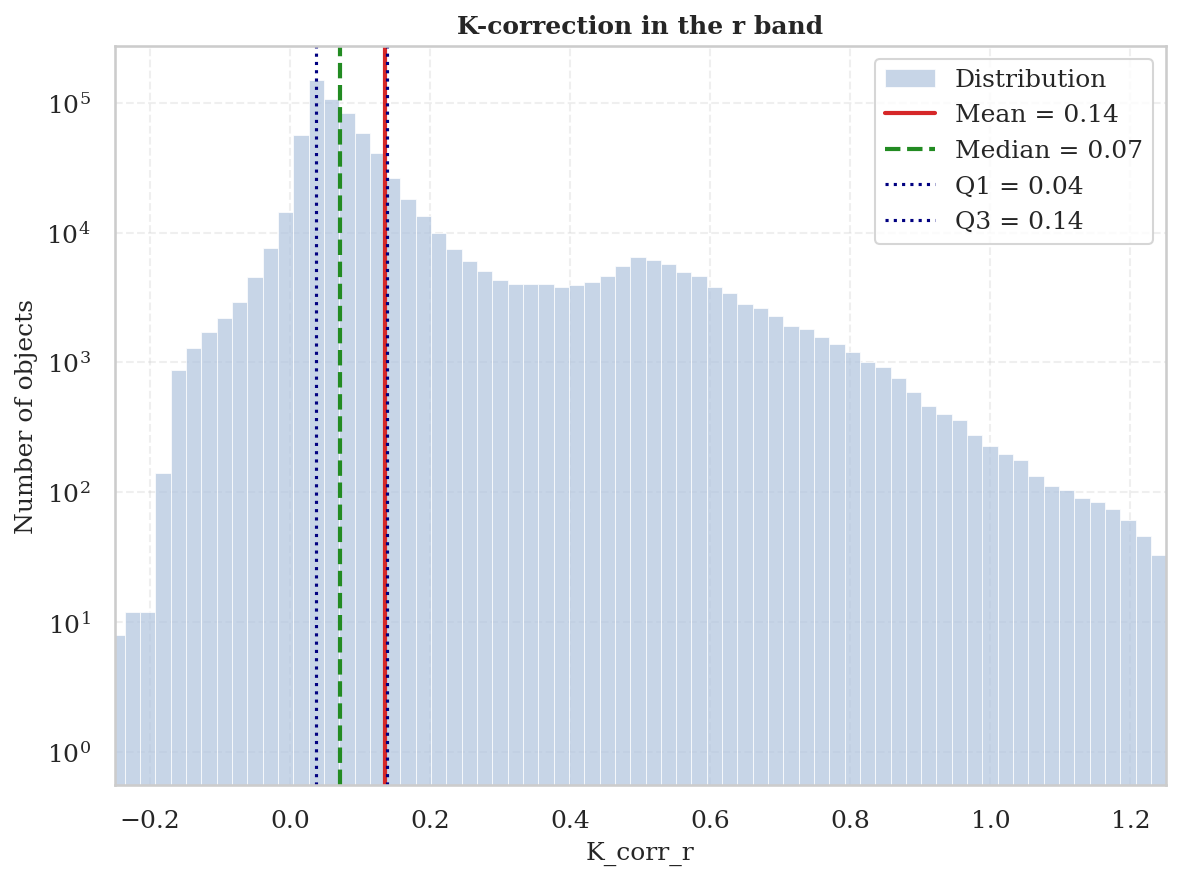

In [72]:
plot_histogram_stats(data = df['K_CORR_R'], 
                     title = 'K-correction in the r band', 
                     xlabel = 'K_corr_r', 
                     color=None, 
                     bins=200,
                     xlim = (-0.25,1.25))

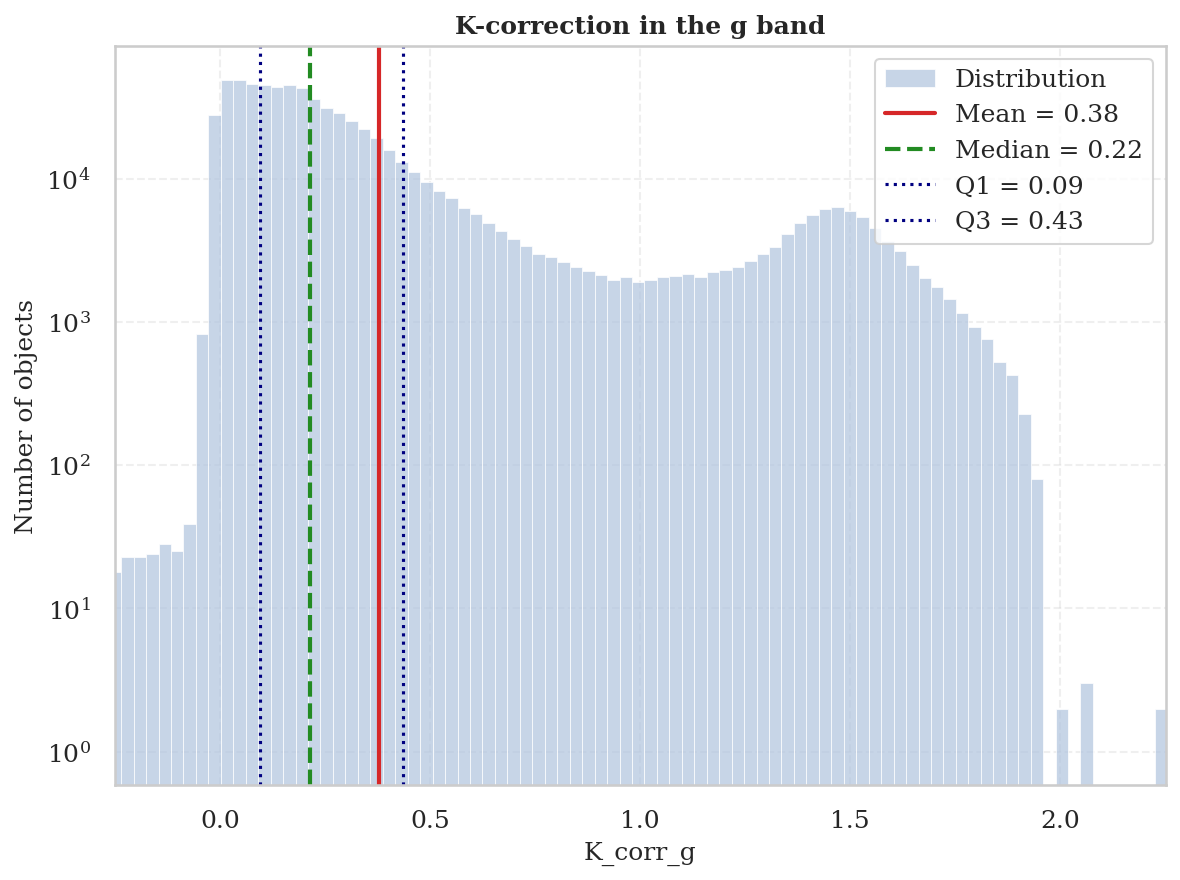

In [73]:
plot_histogram_stats(data = df['K_CORR_G'], 
                     title = 'K-correction in the g band', 
                     xlabel = 'K_corr_g', 
                     color=None, 
                     bins=200,
                     xlim = (-0.25,2.25))

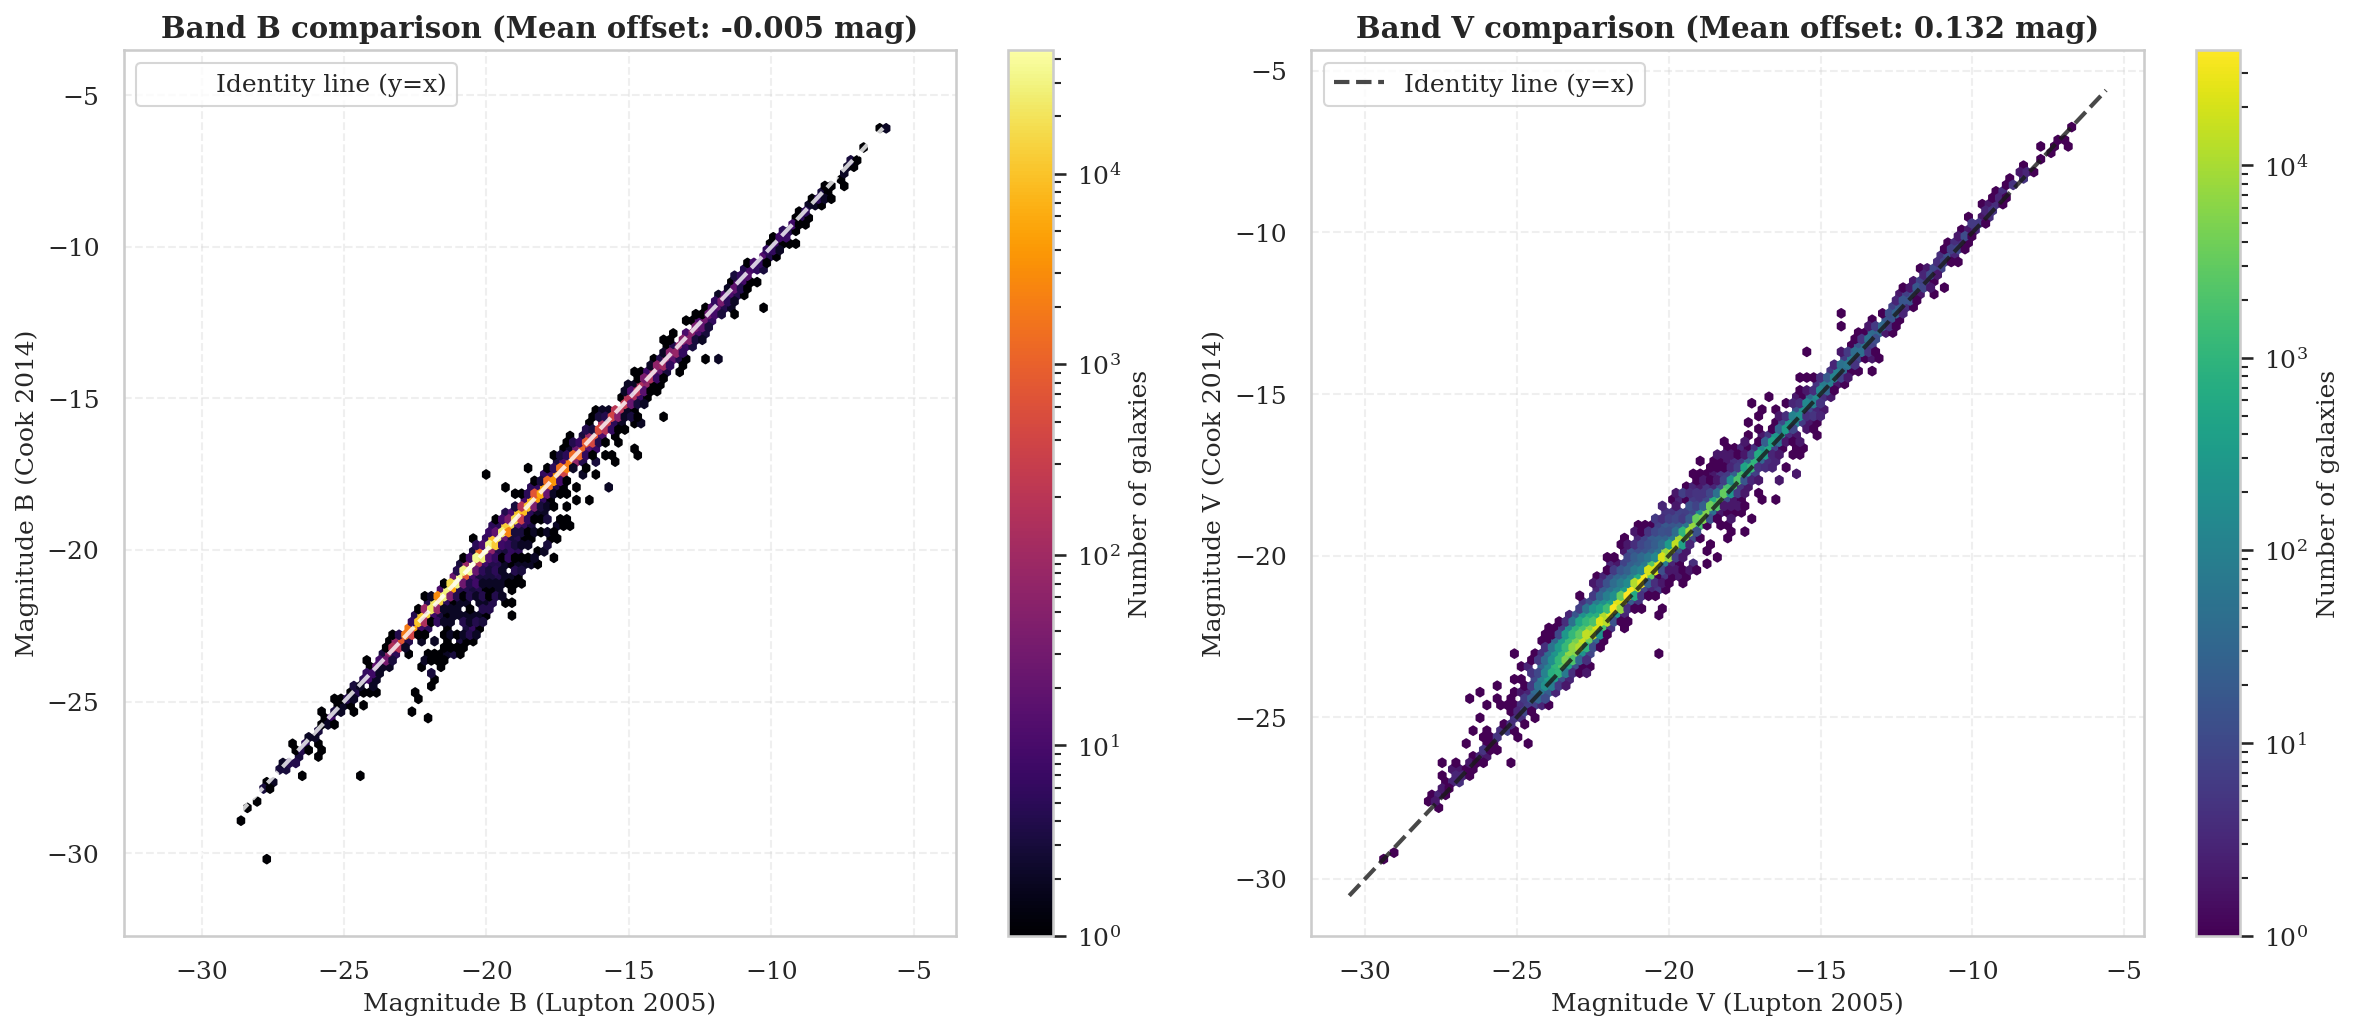

In [74]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

# Variables
x_b = df['ABS_MAG_B']
y_b = df['ABS_MAG_B_Cook']

# Se usa hexbin para manejar la densidad de 700k puntos
hb1 = ax[0].hexbin(x_b, y_b, gridsize=100, cmap='inferno', mincnt=1, bins='log')
cb1 = fig.colorbar(hb1, ax=ax[0])
cb1.set_label('Number of galaxies')

# Línea de identidad (y=x) para referencia
lims_b = [np.min([ax[0].get_xlim(), ax[0].get_ylim()]), # min de ambos ejes
          np.max([ax[0].get_xlim(), ax[0].get_ylim()])] # max de ambos ejes
ax[0].plot(lims_b, lims_b, 'w--', alpha=0.8, linewidth=2, label='Identity line (y=x)')

# Etiquetas
ax[0].set_title(f'Band B comparison (Mean offset: {np.mean(y_b - x_b):.3f} mag)', fontsize=14)
ax[0].set_xlabel('Magnitude B (Lupton 2005)', fontsize=12)
ax[0].set_ylabel('Magnitude B (Cook 2014)', fontsize=12)
ax[0].legend()
ax[0].grid(True, alpha=0.3)

# Variables
x_v = df['ABS_MAG_V']
y_v = df['ABS_MAG_V_Cook']

# Hexbin
hb2 = ax[1].hexbin(x_v, y_v, gridsize=100, cmap='viridis', mincnt=1, bins='log')
cb2 = fig.colorbar(hb2, ax=ax[1])
cb2.set_label('Number of galaxies')

# Línea de identidad
lims_v = [np.min([ax[1].get_xlim(), ax[1].get_ylim()]),  
          np.max([ax[1].get_xlim(), ax[1].get_ylim()])]
ax[1].plot(lims_v, lims_v, 'k--', alpha=0.8, linewidth=2, label='Identity line (y=x)')

# Etiquetas
ax[1].set_title(f'Band V comparison (Mean offset: {np.mean(y_v - x_v):.3f} mag)', fontsize=14)
ax[1].set_xlabel('Magnitude V (Lupton 2005)', fontsize=12)
ax[1].set_ylabel('Magnitude V (Cook 2014)', fontsize=12)
ax[1].legend()
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('comp_bandas.png', dpi=300)
plt.show()

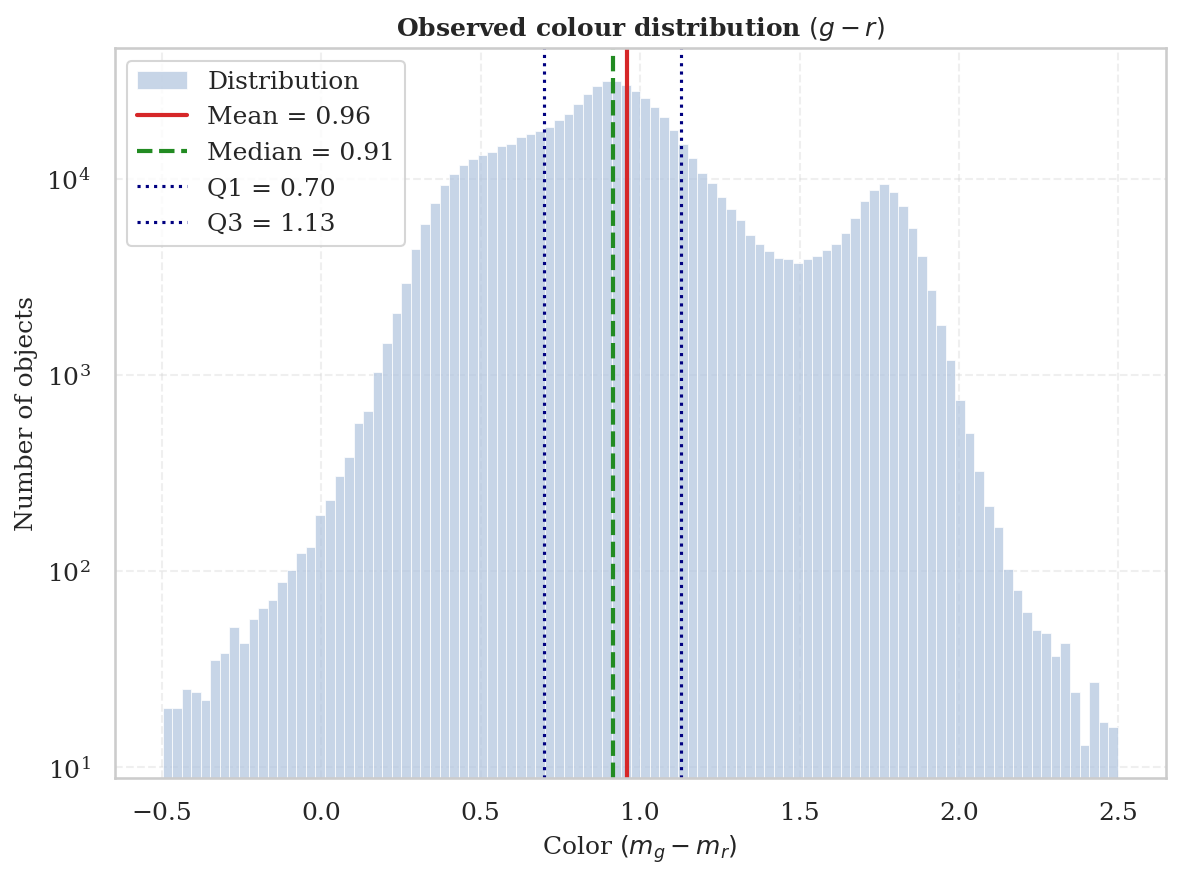

In [75]:
# Calcular el color en reposo (Rest-Frame Color)
df['gr'] = df['modelMag_g'] - df['modelMag_r']

data_color = df['gr'].dropna()
data_color = data_color[ (data_color > -1.0) & (data_color < 3.0) ]

plot_histogram_stats(
    data=data_color,
    title='Observed colour distribution $(g-r)$',
    xlabel='Color $(m_g - m_r)$',
    color=None,      
    bins=100 # 100 barras para ver bien los detalles
)

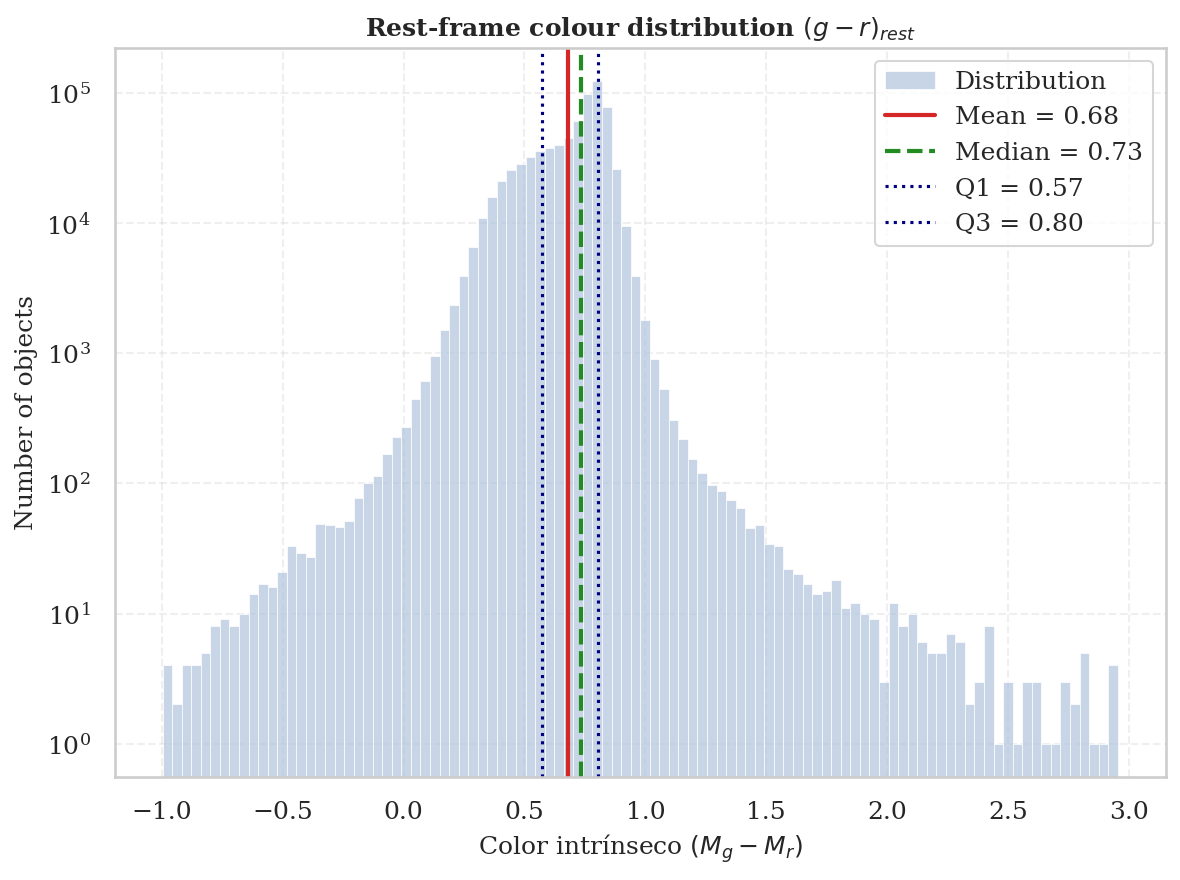

In [76]:
df['gr_REST'] = df['ABS_MAG_g_sdss'] - df['ABS_MAG_r_sdss']

data_color = df['gr_REST'].dropna()
data_color = data_color[ (data_color > -1.0) & (data_color < 3.0) ]

plot_histogram_stats(
    data=data_color,
    title='Rest-frame colour distribution $(g-r)_{rest}$',
    xlabel='Color intrínseco $(M_g - M_r)$',
    color=None,      
    bins=100 
)

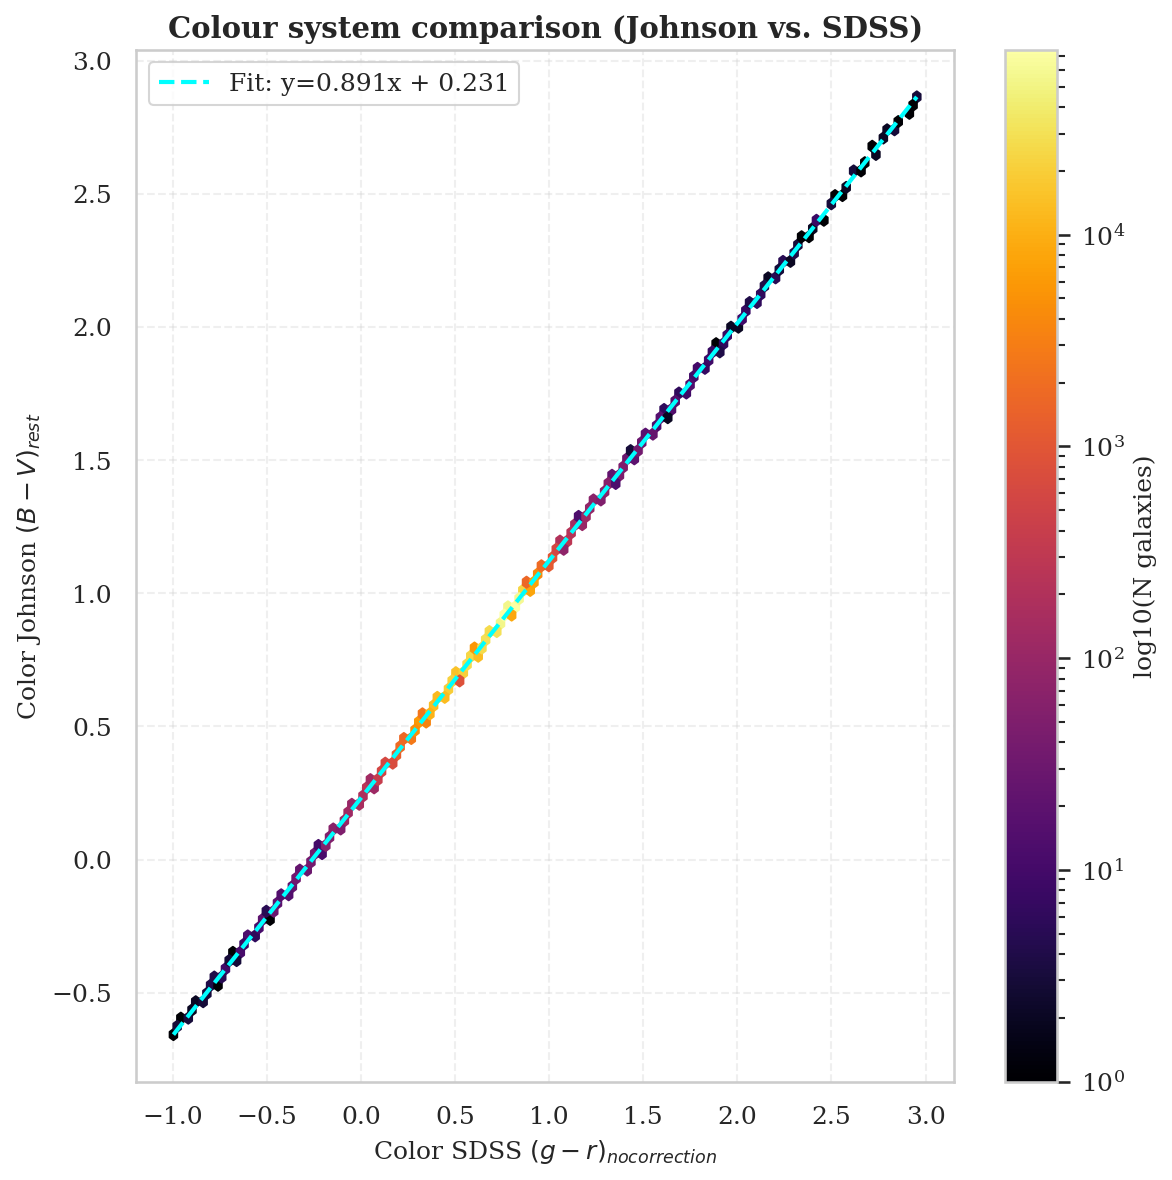

In [77]:
# Se usa magnitudes absolutas en AMBOS lados para que sea el color físico real (rest-frame)
g_r = df['ABS_MAG_g_sdss'] - df['ABS_MAG_r_sdss']
b_v = df['ABS_MAG_B'] - df['ABS_MAG_V']

# Filtramos valores extremos o nulos
mask = (g_r > -1) & (g_r < 3) & (b_v > -1) & (b_v < 3)

x = g_r[mask]
y = b_v[mask]

# Configurar el gráfico
plt.figure(figsize=(8, 8)) # Cuadrada para comparar mejor

# Se usa hexbin porque tiene MUCHOS puntos y el scatter normal se satura
# 'mincnt=1' hace que las celdas vacías sean blancas
hb = plt.hexbin(x, y, gridsize=100, cmap='inferno', mincnt=1, bins='log')
cb = plt.colorbar(hb, label='log10(N galaxies)')

# Ajuste Lineal (Para verificar la ecuación de Lupton)
slope, intercept, r_value, p_value, std_err = stats.linregress(x, y)

# Dibujamos la línea de ajuste
x_fit = np.linspace(x.min(), x.max(), 100)
y_fit = slope * x_fit + intercept

plt.plot(x_fit, y_fit, color='cyan', linestyle='--', linewidth=2, 
         label=f'Fit: y={slope:.3f}x + {intercept:.3f}')

# Etiquetas y Estilo
plt.title('Colour system comparison (Johnson vs. SDSS)', fontsize=14, fontweight='bold')
plt.xlabel('Color SDSS $(g - r)_{no correction}$', fontsize=12)
plt.ylabel('Color Johnson $(B - V)_{rest}$', fontsize=12)

plt.legend(loc='upper left')
plt.grid(True, alpha=0.3, linestyle='--')

plt.show()

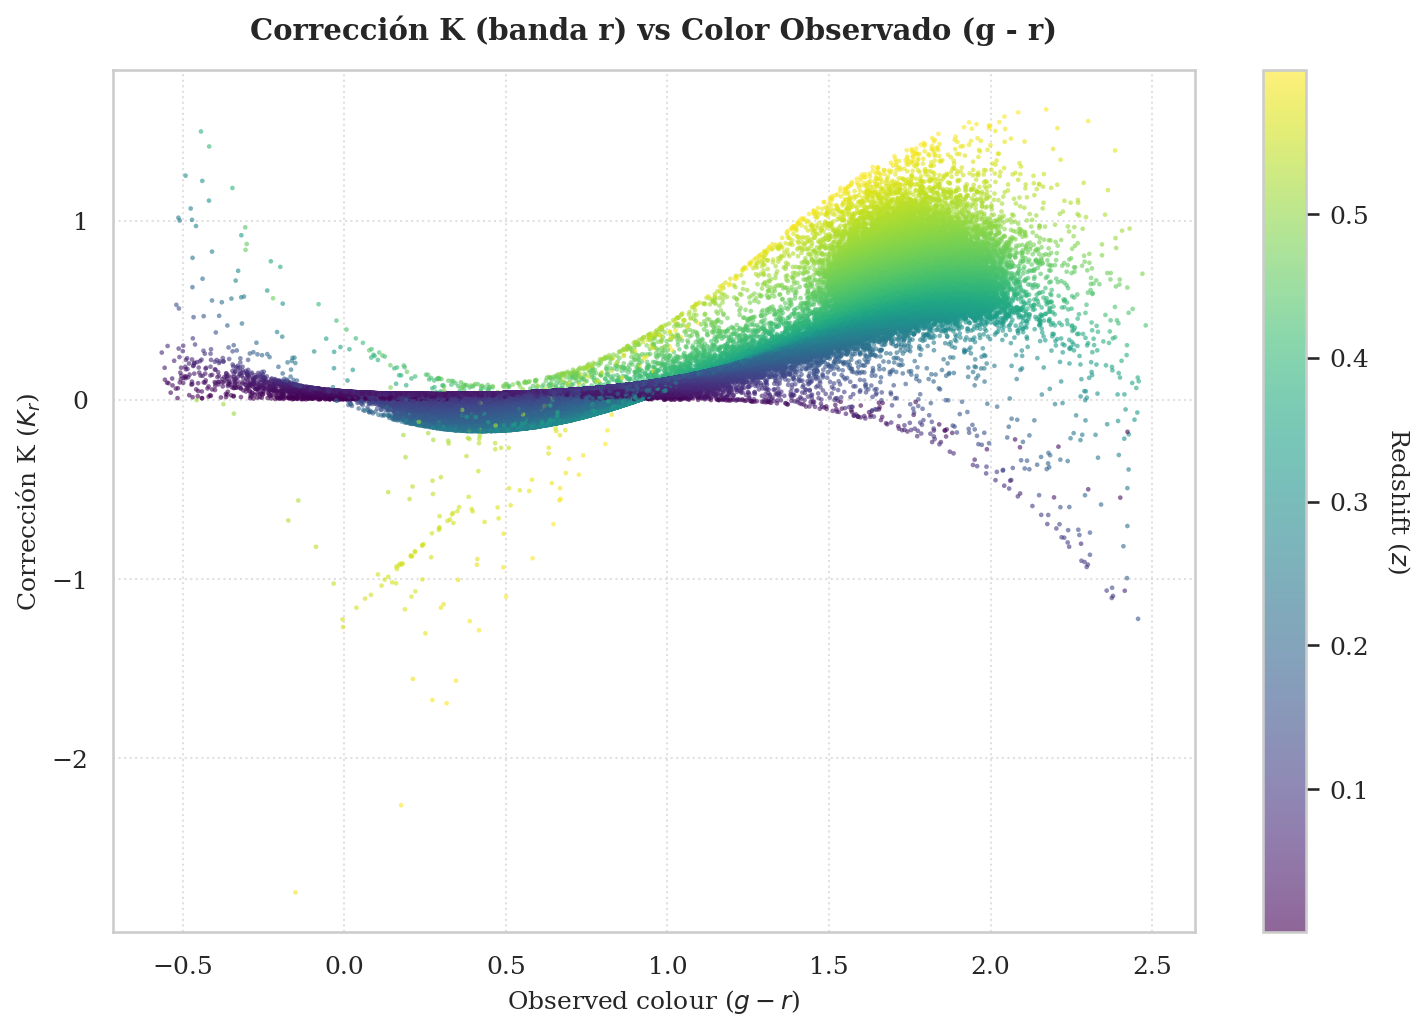

In [78]:
color_obs = pd.to_numeric(df['modelMag_g_corr'] - df['modelMag_r_corr'], errors='coerce')
k_corr = pd.to_numeric(df['K_CORR_R'], errors='coerce')
z_redshift = pd.to_numeric(df['Z'], errors='coerce')

mask = np.isfinite(color_obs) & np.isfinite(k_corr) & np.isfinite(z_redshift)

x = color_obs[mask]
y = k_corr[mask]
z = z_redshift[mask]

plt.figure(figsize=(10, 7))
# Scatter plot: x=Color, y=Corrección K, color del punto (c) = Redshift
scatter = plt.scatter(x, y, c=z, cmap='viridis', s=5, alpha=0.6, edgecolors='none')
# Añadir barra de color para el Redshift
cbar = plt.colorbar(scatter)
cbar.set_label('Redshift ($z$)', rotation=270, labelpad=20, fontsize=12)

plt.title('Corrección K (banda r) vs Color Observado (g - r)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Observed colour ($g - r$)', fontsize=12)
plt.ylabel('Corrección K ($K_r$)', fontsize=12)

plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

## 7. Análisis de calidad espectral: comparación SNR(H$\beta$) > 3 vs SNR > 5

Antes de aplicar el corte definitivo de calidad espectral, evaluamos si la elección del umbral de relación señal-ruido (SNR) en H$\beta$ introduce **sesgos sistemáticos** en las propiedades físicas de la muestra.

Se define dos muestras anidadas:
- **Muestra base** (SNR > 3): máxima completitud, incluye espectros más ruidosos.
- **Muestra de alta calidad** (SNR > 5): subconjunto más limpio, con medidas de líneas de emisión más fiables.

La pregunta científica es: *¿el corte más estricto elimina galaxias de forma aleatoria, o preferentemente excluye ciertos tipos de objetos?*


>> Distribución de relación señal/ruido (H beta):
Figura guardada en: sn_hbeta.png


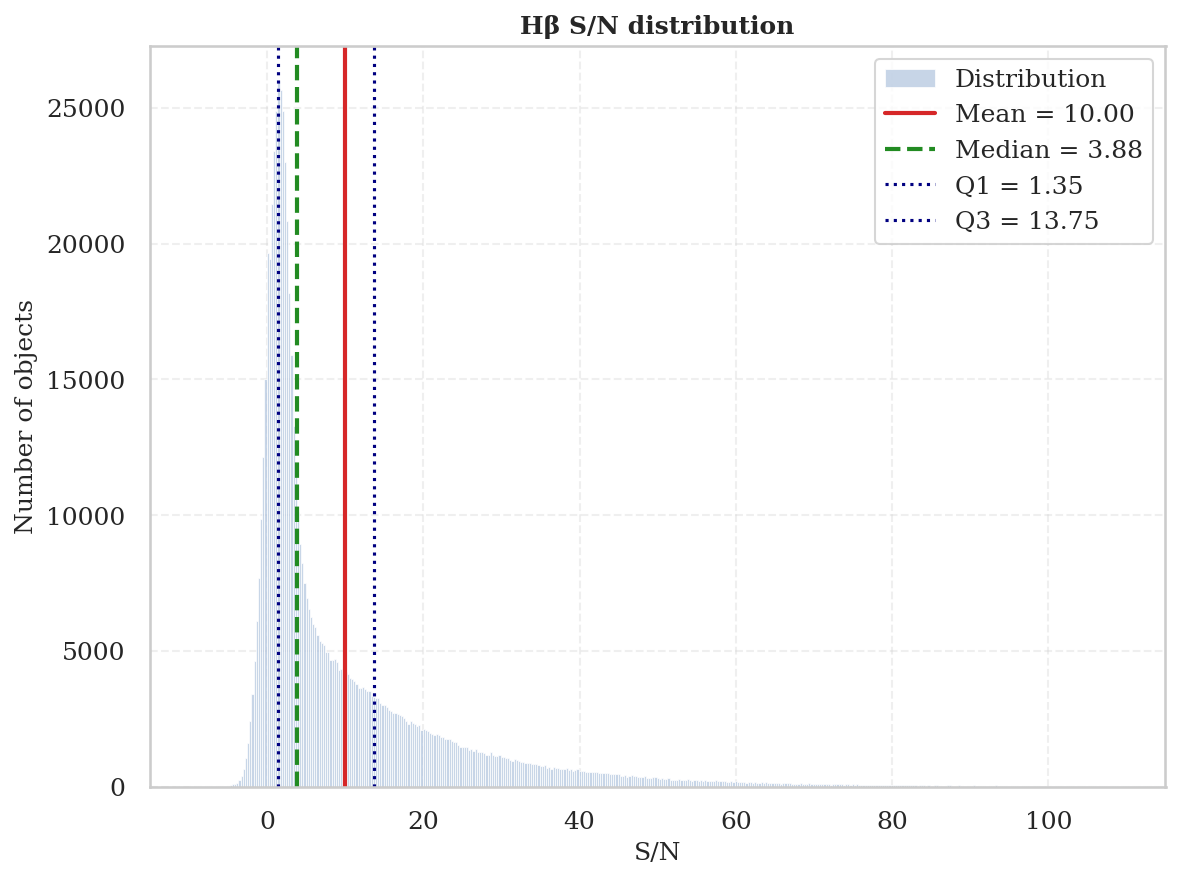

In [79]:
print("\n>> Distribución de relación señal/ruido (H beta):")
plot_histogram_stats(df['SN_HB'], 
                     "Hβ S/N distribution", 
                     "S/N", color=None,
                     xlim = (-15,115),
                     save_path = 'sn_hbeta.png',
                     log=False)


In [80]:
# Se calcula la luminosidad H beta para usarla más adelante
if 'L_HB_Log' not in df.columns:
    print("Calculando luminosidades...")
    df['L_HB_Log'] = np.nan
    
    # Máscara de datos válidos
    mask_valid_physics = (df['H_BETA_FLUX'] > 0)
    
    cosmo = FlatLambdaCDM(H0=70, Om0=0.3)
    z_values = df.loc[mask_valid_physics, 'Z'].values
    dist_cm = cosmo.luminosity_distance(z_values).to(u.cm).value
    
    flux_cgs = df.loc[mask_valid_physics, 'H_BETA_FLUX'] * 1e-17
    lum_erg_s = 4 * np.pi * dist_cm**2 * flux_cgs
    
    df.loc[mask_valid_physics, 'L_HB_Log'] = np.log10(lum_erg_s)
    print(f"Luminosidad calculada. {len(df) - mask_valid_physics.sum()} galaxias ignoradas por no ser emisión.")

Calculando luminosidades...
Luminosidad calculada. 71415 galaxias ignoradas por no ser emisión.


### 7.1 Tamaño de las muestras

Se aplica ambos umbrales sobre el catálogo filtrado por calidad (RELIABLE = 1, Z_WARNING = 0) y cuantificamos las galaxias retenidas y perdidas.

In [81]:
snr3 = df[df['SN_HB'] > 3].copy()
snr5 = df[df['SN_HB'] > 5].copy()

print(f"SNR > 3: {len(snr3):,} galaxias")
print(f"SNR > 5: {len(snr5):,} galaxias")
print(f"Fracción retenida: {len(snr5)/len(snr3):.1%}")
print(f"Galaxias perdidas: {len(snr3)-len(snr5):,}")

SNR > 3: 398,345 galaxias
SNR > 5: 322,035 galaxias
Fracción retenida: 80.8%
Galaxias perdidas: 76,310


### 7.2 Test de Anderson-Darling sobre la masa estelar

El **test de Anderson-Darling para k muestras** () evalúa si dos o más distribuciones empíricas provienen de la misma distribución poblacional. Es más sensible que el test KS en las colas de la distribución, lo que lo hace especialmente adecuado para detectar diferencias en los extremos de la función de masa estelar.

**Parámetros clave:**
- **Estadístico A²**: cuantifica la discrepancia acumulada entre las distribuciones. Valores altos indican mayor diferencia.
- **p-valor**: probabilidad de observar esa discrepancia si ambas muestras fueran idénticas. Un p-valor < 0.05 lleva a rechazar la hipótesis nula de igualdad.

En este caso comparamos las galaxias con SNR > 5 (muestra de alta calidad) contra las que quedan excluidas al subir el umbral (3 < SNR ≤ 5), para determinar si estas últimas son poblacionalmente distintas.

In [82]:
def plot_ecdf(ax, data, label, color, lw=2, ls='-'):
    """ECDF sin el artefacto de caída final de ax.hist(cumulative=True)."""
    x = np.sort(data)
    y = np.arange(1, len(x) + 1) / len(x)
    ax.plot(x, y, color=color, lw=lw, ls=ls, label=label)

Test de Anderson-Darling: impacto del umbral S/N en la masa estelar
Galaxias SNR > 5       : 318,471
Galaxias 3 < SNR <= 5  : 72,380
Estadístico A²         : 36484.6172
p-valor                : 1.00e-03


/var/folders/9s/8lptc9x51kqf0y6df6gp74180000gn/T/ipykernel_16039/3454565135.py:16: UserWarning: p-value floored: true value smaller than 0.001. Consider specifying `method` (e.g. `method=stats.PermutationMethod()`.)
  ad_result = stats.anderson_ksamp([data_excelente, data_dudosa], variant='midrank')


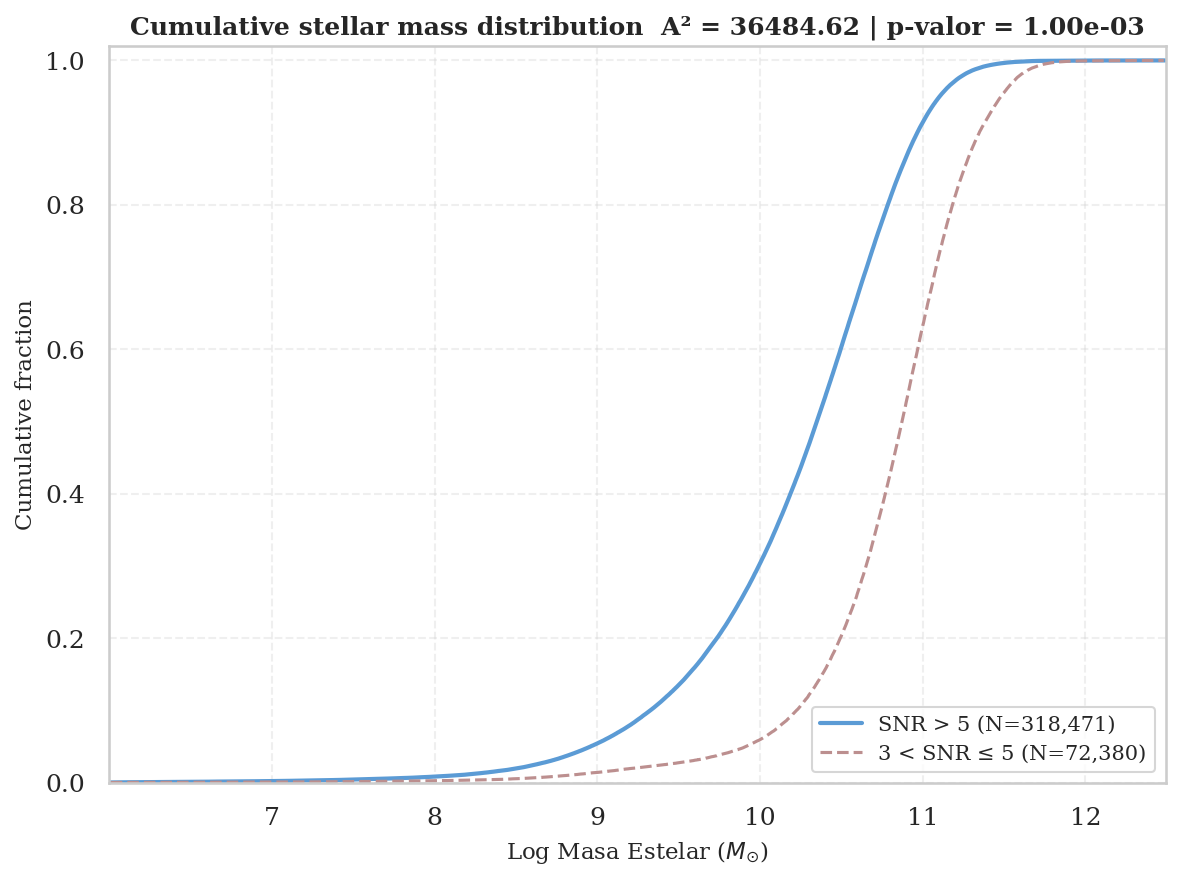


CONCLUSIÓN
Se rechaza la hipótesis nula: las galaxias excluidas al subir el umbral
son estadísticamente diferentes de las de SNR > 5.


In [83]:
#import warnings
#warnings.filterwarnings("ignore", category=UserWarning, module="scipy.stats")

variable_a_testear = 'LGM_TOT_P50'
label_grafico = 'Log Masa Estelar ($M_⊙$)'

# Solo valores físicamente válidos (elimina -9999 y NaN)
mask_fisica = df[variable_a_testear] > 5.0

mask_excelente = df['SN_HB'] > 5
mask_dudosa = (df['SN_HB'] > 3) & (df['SN_HB'] <= 5)

data_excelente = df.loc[mask_excelente & mask_fisica, variable_a_testear].dropna().values
data_dudosa    = df.loc[mask_dudosa    & mask_fisica, variable_a_testear].dropna().values

ad_result = stats.anderson_ksamp([data_excelente, data_dudosa], variant='midrank')

print("Test de Anderson-Darling: impacto del umbral S/N en la masa estelar")
print(f"Galaxias SNR > 5       : {len(data_excelente):,}")
print(f"Galaxias 3 < SNR <= 5  : {len(data_dudosa):,}")
print(f"Estadístico A²         : {ad_result.statistic:.4f}")
print(f"p-valor                : {ad_result.pvalue:.2e}")


xlims = (min(data_excelente.min(), data_dudosa.min()),
         max(data_excelente.max(), data_dudosa.max()))

fig, ax = plt.subplots(figsize=(8, 6))

plot_ecdf(ax, data_excelente,
          label=f'SNR > 5 (N={len(data_excelente):,})',
          color=TFM_COLORS['snr_estricto'], lw=2)

plot_ecdf(ax, data_dudosa,
          label=f'3 < SNR ≤ 5 (N={len(data_dudosa):,})',
          color=TFM_COLORS['snr_dudoso'], lw=1.5, ls='--')

ax.set_xlim(xlims)
ax.set_ylim(0, 1.02)
ax.set_title(f"Cumulative stellar mass distribution  "
             f"A² = {ad_result.statistic:.2f} | p-valor = {ad_result.pvalue:.2e}",
             fontsize=12, fontweight='bold')
ax.set_xlabel(label_grafico, fontsize=11)
ax.set_ylabel("Cumulative fraction", fontsize=11)
ax.legend(loc='lower right', fontsize=10)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

print("\nCONCLUSIÓN")
if ad_result.pvalue < 0.05:
    print("Se rechaza la hipótesis nula: las galaxias excluidas al subir el umbral")
    print("son estadísticamente diferentes de las de SNR > 5.")
else:
    print("No se rechaza la hipótesis nula: ambos subgrupos son estadísticamente indistinguibles.")

### 7.3 Test de Kolmogorov-Smirnov sobre propiedades físicas y observacionales

El **test de Kolmogorov-Smirnov de dos muestras** mide la distancia máxima (estadístico D) entre las funciones de distribución acumulada (CDF) de dos muestras independientes. En las gráficas siguientes, D corresponde visualmente a la separación vertical máxima entre las dos curvas.

**Parámetros:**
- **D (KS stat)**: distancia máxima entre CDFs, en el rango [0, 1]. D = 0 indica distribuciones idénticas; D = 1 indica separación total.
- **p-valor**: con muestras de cientos de miles de objetos, casi cualquier diferencia resulta estadísticamente significativa (p ≈ 0). El **tamaño del efecto D** es el indicador relevante: D < 0.05 es despreciable; 0.05–0.10 es moderado; D > 0.10 es notable.

Aquí comparamos la muestra SNR > 3 completa frente a la muestra SNR > 5, evaluando si el corte introduce sesgos en redshift, fotometría, masa estelar, SFR, color, índice D4000 y las líneas de emisión. Previamente se han sustituido los valores centinela -9999 del catálogo MPA-JHU por NaN y se utiliza la anchura equivalente en reposo (REQW) de H$\beta$ con signo invertido, de modo que la emisión toma valores positivos.

Propiedad             N(snr3)  N(snr5)   D stat    p-valor   Δmediana     Efecto
──────────────────────────────────────────────────────────────────────────────────
Stellar MAss          390,851  318,471   0.0763   0.00e+00    -0.1060  moderado  ***
log SFR               375,988  307,479   0.0831   0.00e+00     0.1061  moderado  ***
Redshift              398,345  322,035   0.0346  1.15e-185    -0.0046  despreciable  ***
Color g-r REST        398,345  322,035   0.1212   0.00e+00    -0.0391  notable  ***
Mag abs r             398,345  322,035   0.0613   0.00e+00     0.1648  moderado  ***
D4000_N               398,345  322,035   0.1324   0.00e+00    -0.0495  notable  ***
log L(Hbeta)          398,345  322,035   0.0462   0.00e+00     0.0670  despreciable  ***
EW Hbeta (rest)       398,325  322,015   0.1258   0.00e+00     0.6639  notable  ***
Metallicity           156,588  156,588   0.0000   1.00e+00     0.0000  despreciable  


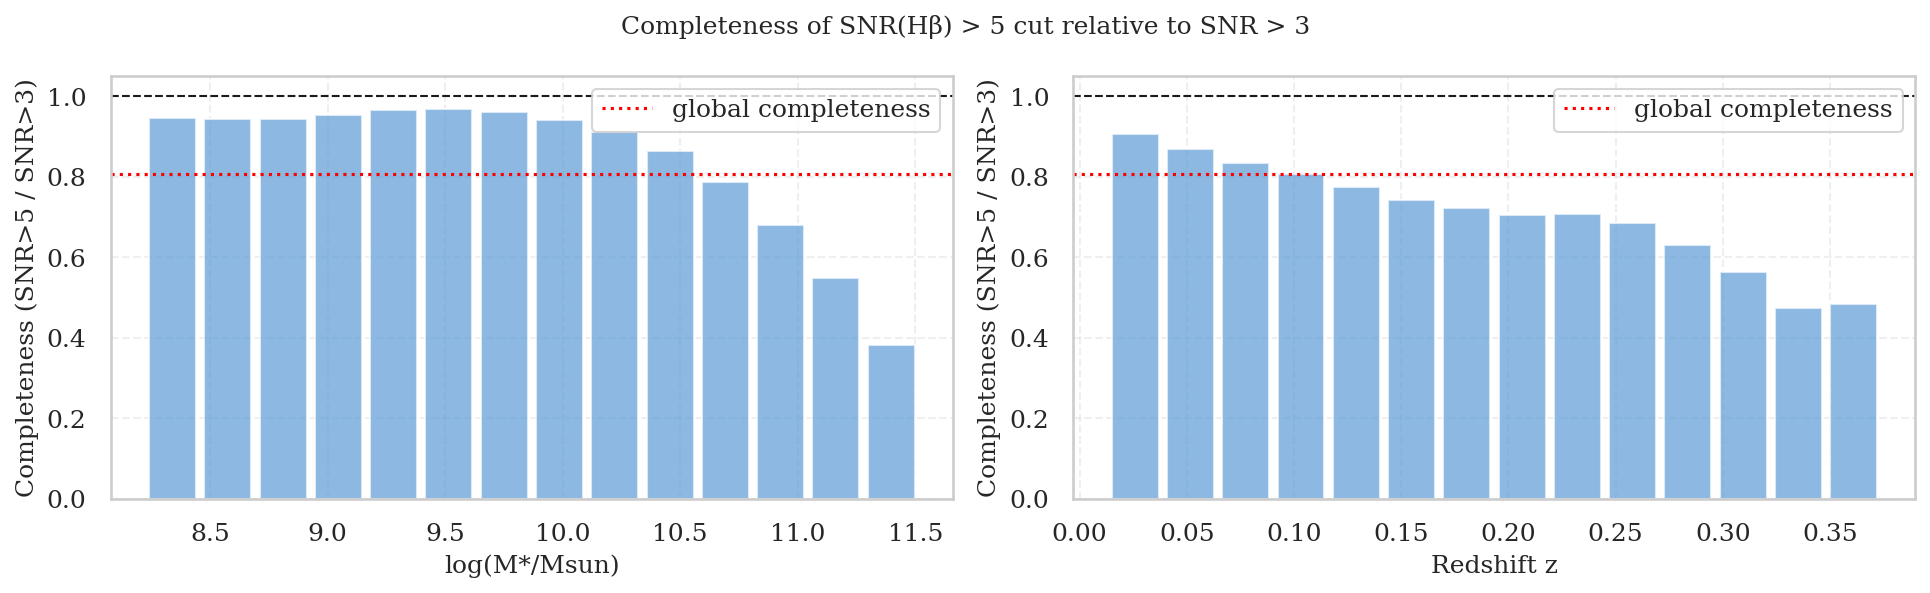

/var/folders/9s/8lptc9x51kqf0y6df6gp74180000gn/T/ipykernel_16039/2242097039.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


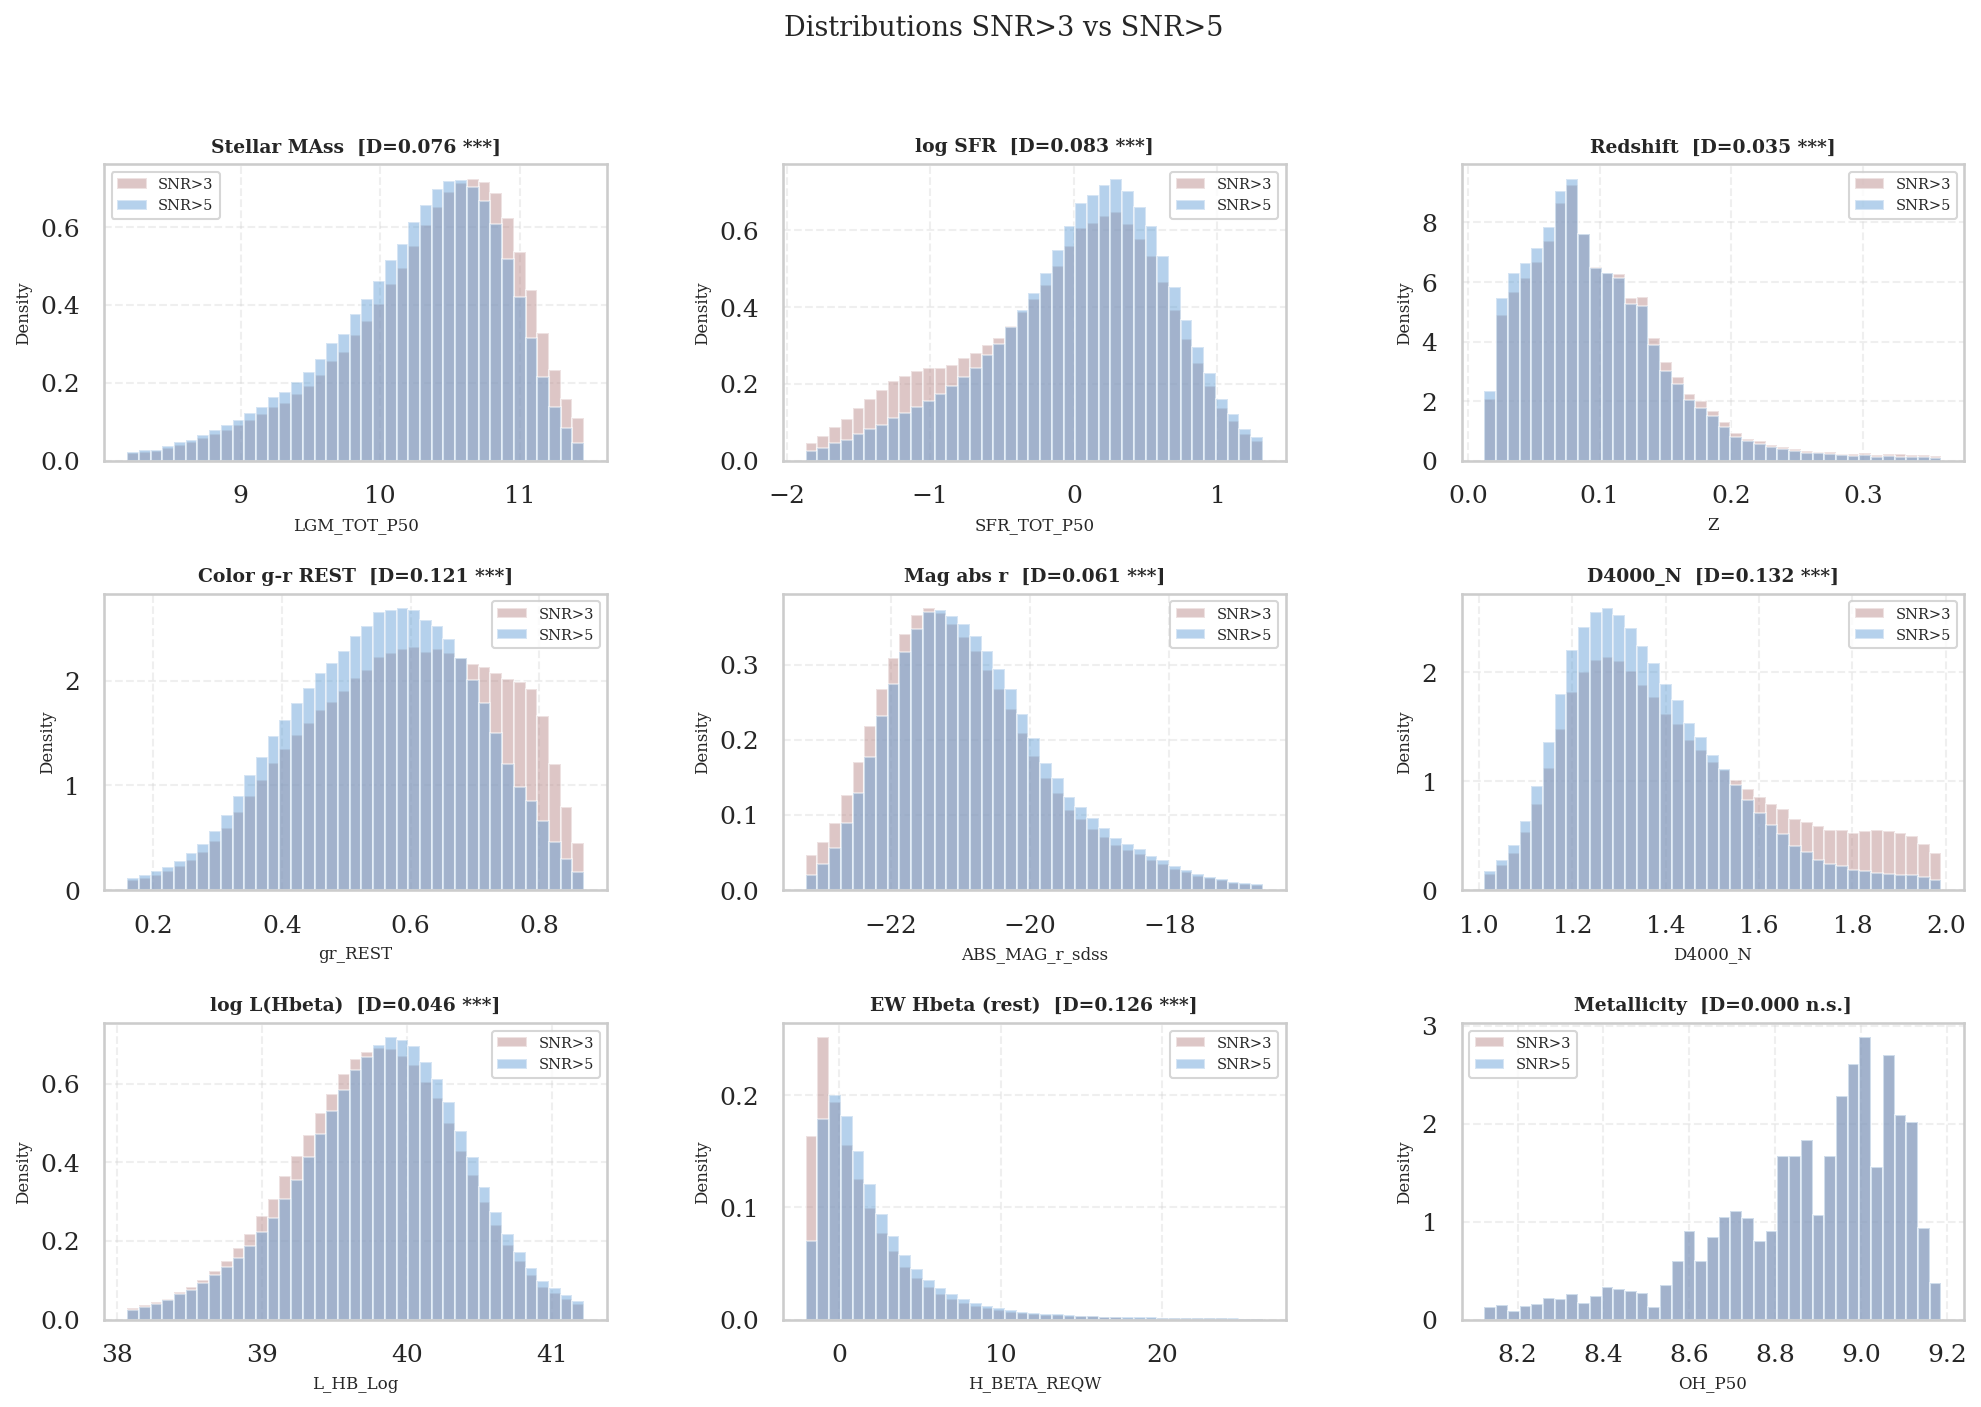


── Distribución BPTCLASS ──

SNR>3:
  No clasificada   (clase -1): 7.7%
  Star-forming     (clase  1): 40.3%
  Compuesta        (clase  2): 28.6%
  AGN Seyfert      (clase  3): 9.5%
  AGN LINER        (clase  4): 4.3%
  Absorbcion       (clase  5): 9.7%

SNR>5:
  No clasificada   (clase -1): 1.6%
  Star-forming     (clase  1): 49.9%
  Compuesta        (clase  2): 28.0%
  AGN Seyfert      (clase  3): 11.7%
  AGN LINER        (clase  4): 5.3%
  Absorbcion       (clase  5): 3.5%


In [84]:
# Invertir signo de REQW para que emisión sea positiva
df['H_BETA_REQW'] = df['H_BETA_REQW'] * -1
df.loc[df['H_BETA_REQW'] < -20,  'H_BETA_REQW'] = np.nan
df.loc[df['H_BETA_REQW'] > 200,  'H_BETA_REQW'] = np.nan

propiedades = {
    'Stellar MAss'    : 'LGM_TOT_P50',
    'log SFR'         : 'SFR_TOT_P50',
    'Redshift'        : 'Z',
    'Color g-r REST'  : 'gr_REST',
    'Mag abs r'       : 'ABS_MAG_r_sdss',
    'D4000_N'         : 'D4000_N',
    'log L(Hbeta)'    : 'L_HB_Log',
    'EW Hbeta (rest)' : 'H_BETA_REQW',
    'Metallicity'     : 'OH_P50',
}

cols_needed = ['SN_HB'] + list(propiedades.values()) + ['BPTCLASS']

# Vistas ligeras — sin .copy(), sin duplicar memoria
snr3 = df.loc[df['SN_HB'] > 3, cols_needed]
snr5 = df.loc[df['SN_HB'] > 5, cols_needed]

print(f"{'Propiedad':<20} {'N(snr3)':>8} {'N(snr5)':>8} "
      f"{'D stat':>8} {'p-valor':>10} {'Δmediana':>10} {'Efecto':>10}")
print("─" * 82)

resultados = []
for nombre, col in propiedades.items():
    a = snr3[col].replace(-9999, np.nan).dropna()
    b = snr5[col].replace(-9999, np.nan).dropna()
    if len(a) < 10 or len(b) < 10:
        continue
    ks_s, ks_p = stats.ks_2samp(a, b)
    delta_med  = np.median(b) - np.median(a)
    efecto     = "despreciable" if ks_s < 0.05 else ("moderado" if ks_s < 0.10 else "notable")
    sig        = '***' if ks_p < 0.001 else ('**' if ks_p < 0.01 else ('*' if ks_p < 0.05 else ''))
    print(f"{nombre:<20} {len(a):>8,} {len(b):>8,} "
          f"{ks_s:>8.4f} {ks_p:>10.2e} {delta_med:>10.4f}  {efecto}  {sig}")
    resultados.append({'nombre': nombre, 'col': col, 'ks_s': ks_s,
                        'ks_p': ks_p, 'delta_med': delta_med})

# Completeness por masa y redshift 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in zip(axes,
                           ['LGM_TOT_P50', 'Z'],
                           ['log(M*/Msun)', 'Redshift z']):
    data3 = snr3[col].replace(-9999, np.nan).dropna()
    data5 = snr5[col].replace(-9999, np.nan).dropna()
    bins  = np.linspace(data3.quantile(0.01), data3.quantile(0.99), 15)
    n3, _ = np.histogram(data3, bins=bins)
    n5, _ = np.histogram(data5, bins=bins)
    comp  = np.where(n3 > 0, n5 / n3, np.nan)
    mids  = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(mids, comp, width=np.diff(bins)*0.85, color=TFM_COLORS['snr_estricto'], alpha=0.7)
    ax.axhline(1.0, color='k', lw=1, ls='--')
    ax.axhline(len(snr5)/len(snr3), color='red', lw=1.5, ls=':', label='global completeness')
    ax.set_xlabel(label); ax.set_ylabel('Completeness (SNR>5 / SNR>3)')
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Completeness of SNR(Hβ) > 5 cut relative to SNR > 3', fontsize=12)
plt.tight_layout()
plt.savefig('completeness_hb.png', dpi=300)
plt.show()

# Distribuciones superpuestas
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(3, 3, hspace=0.45, wspace=0.35)
for idx, r in enumerate(resultados):
    ax = fig.add_subplot(gs[idx // 3, idx % 3])
    a  = snr3[r['col']].replace(-9999, np.nan).dropna()
    b  = snr5[r['col']].replace(-9999, np.nan).dropna()
    lo, hi = np.percentile(pd.concat([a, b]), [1, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(a, bins=bins, density=True, alpha=0.5, color=TFM_COLORS['snr_dudoso'], label='SNR>3')
    ax.hist(b, bins=bins, density=True, alpha=0.45, color=TFM_COLORS['snr_estricto'], label='SNR>5')
    sig = '***' if r['ks_p'] < 0.001 else ('**' if r['ks_p'] < 0.01 else ('*' if r['ks_p'] < 0.05 else 'n.s.'))
    ax.set_title(f"{r['nombre']}  [D={r['ks_s']:.3f} {sig}]", fontsize=9)
    ax.set_xlabel(r['col'], fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Distributions SNR>3 vs SNR>5', fontsize=13)
plt.tight_layout()
plt.savefig('distribuciones_hb.png', dpi=300)
plt.show()

# Distribución BPTCLASS
print("\n── Distribución BPTCLASS ──")
for muestra, nombre in [(snr3, 'SNR>3'), (snr5, 'SNR>5')]:
    counts = muestra['BPTCLASS'].value_counts(normalize=True).sort_index()
    print(f"\n{nombre}:")
    labels = {-1: 'No clasificada', 1: 'Star-forming', 2: 'Compuesta',
              3: 'AGN Seyfert',   4: 'AGN LINER',   5: 'Absorbcion'}
    for k, v in counts.items():
        print(f"  {labels.get(k, str(k)):<16} (clase {k:2d}): {v:.1%}")

### 7.4 Interpretación de los resultados

Los tests confirman que el corte SNR(H$\beta$) > 5 **no es neutro**: introduce sesgos sistemáticos respecto a la muestra SNR > 3. Sin embargo, estos sesgos son **coherentes con el objetivo científico** de este trabajo, que se centra en galaxias enanas con formación estelar activa:

| Sesgo detectado | D | Δmediana | Relevancia para este trabajo |
|---|---|---|---|
| Masa estelar | 0.076 | −0.10 dex | Favorece galaxias menos masivas → **compatible** con enanas |
| Color g−r REST | 0.121 | −0.039 mag | Favorece objetos más azules → **compatible** con SF activa |
| D4000_N | 0.132 | −0.049 | Favorece poblaciones estelares jóvenes → **compatible** |
| log SFR | 0.087 | +0.11 dex | Favorece mayor formación estelar → **compatible** |
| Redshift | 0.034 | −0.005 | Sesgo leve hacia z menor → **aceptable** |
| BPTCLASS SF | — | de 40% a 50% | La fracción SF aumenta → **favorable** |

La completeness es alta (> 85%) para galaxias con log(M\star$) < 10.5 M\odot$ y z < 0.15, que son precisamente las enanas a redshift bajo que constituyen la muestra objetivo. La pérdida de galaxias se concentra en objetos masivos y pasivos que se excluirán igualmente en el corte de selección final.

> **Nota metodológica**: con muestras de ∼350 000 objetos, el p-valor del test KS es sistemáticamente cero para cualquier diferencia real. El estadístico D es el indicador relevante del tamaño del efecto.

## 8. Efecto del corte en redshift sobre la distribución de masa

El SDSS presenta limitaciones fotométricas que se vuelven relevantes a $ z > 0.24$: las correcciones K se vuelven menos precisas y la fibra espectroscópica de 3" cubre una fracción creciente del tamaño angular de la galaxia, introduciendo efectos de apertura. Por ello se considera un corte en $z < 0.24$.

Se aplica de nuevo el test de Kolmogorov-Smirnov para evaluar si este corte en redshift sesga la distribución de masa estelar de la muestra.

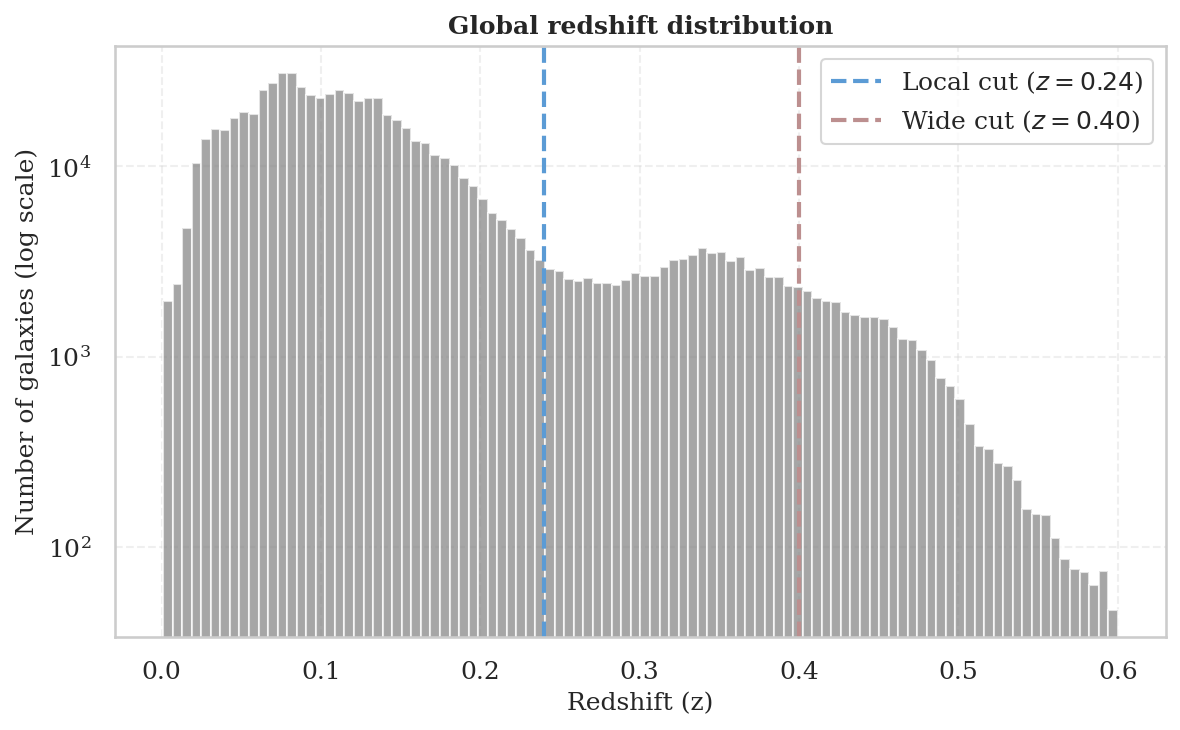

In [85]:
# Histograma de redshift con el corte
plt.figure(figsize=(8, 5))
plt.hist(df['Z'], bins=100, color='gray', alpha=0.7, log=True)
plt.axvline(0.24, color=TFM_COLORS['snr_estricto'], linestyle='--', lw=2, label='Local cut ($z = 0.24$)')
plt.axvline(0.40, color=TFM_COLORS['snr_dudoso'], linestyle='--', lw=2, label='Wide cut ($z = 0.40$)')
plt.title("Global redshift distribution")
plt.xlabel("Redshift (z)")
plt.ylabel("Number of galaxies (log scale)")
plt.legend(); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

z < 0.40 : 684,527 galaxias
z < 0.24 : 608,116 galaxias
Fracción retenida: 88.8%
Galaxias perdidas: 76,411

Propiedad             N(z<0.40)  N(z<0.24)   D stat    p-valor   Δmediana       Efecto
────────────────────────────────────────────────────────────────────────────────────────
Stellar Mass            648,156    607,727   0.0426   0.00e+00    -0.0379  despreciable ***
log SFR                 621,359    585,523   0.0099   2.48e-26     0.0045  despreciable ***
Color g-r REST          684,527    608,116   0.0514   0.00e+00    -0.0196  moderado     ***
Mag abs r               684,527    608,116   0.0830   0.00e+00     0.1579  moderado     ***
D4000_N                 684,527    608,116   0.0440   0.00e+00    -0.0594  despreciable ***
log L(Hbeta)            622,619    564,969   0.0292  4.19e-219    -0.0455  despreciable ***
EW Hbeta (rest)         684,501    608,091   0.0312  3.46e-272     0.1182  despreciable ***
SNR Hbeta               684,527    608,116   0.0495   0.00e+00     1.126

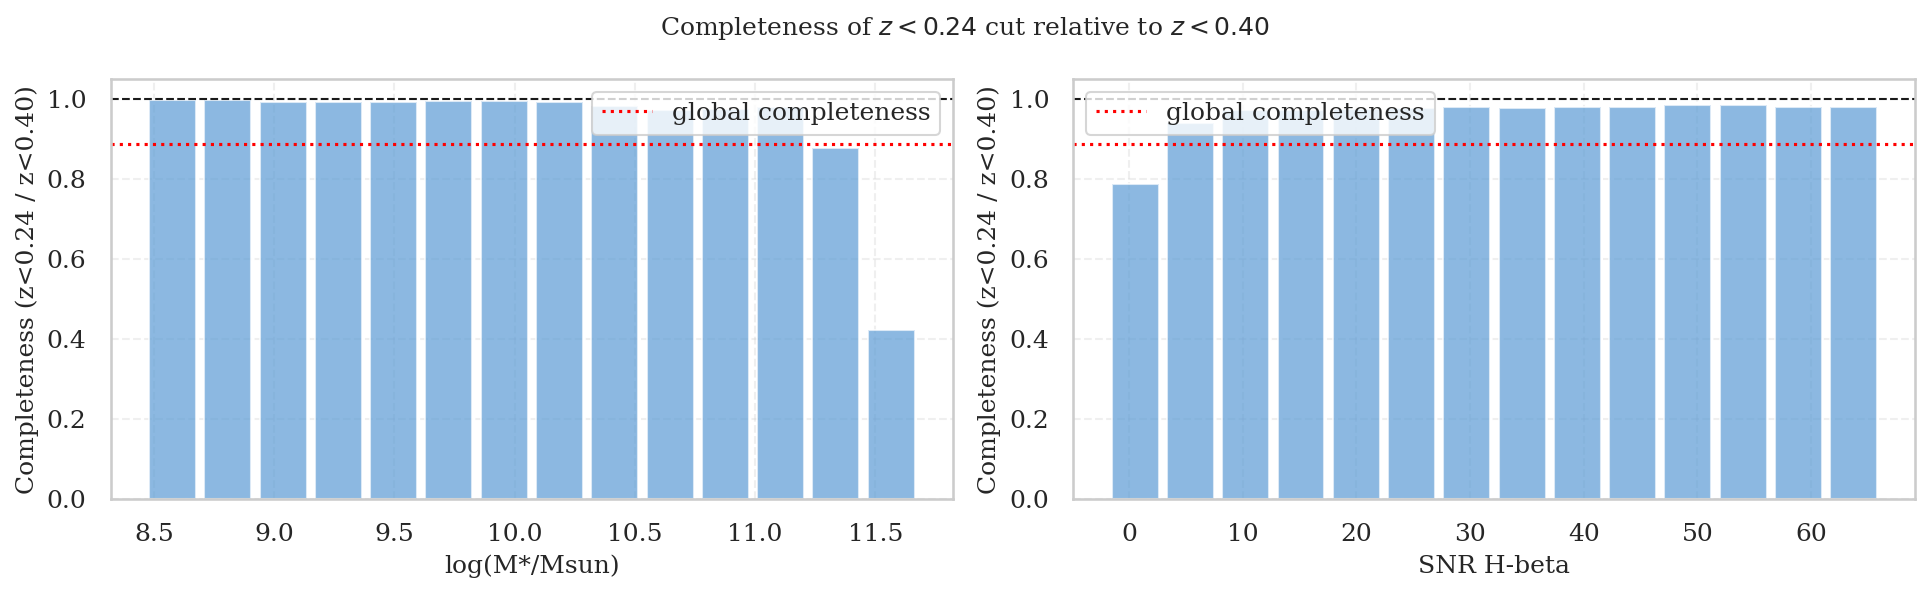

/var/folders/9s/8lptc9x51kqf0y6df6gp74180000gn/T/ipykernel_16039/1732155192.py:85: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


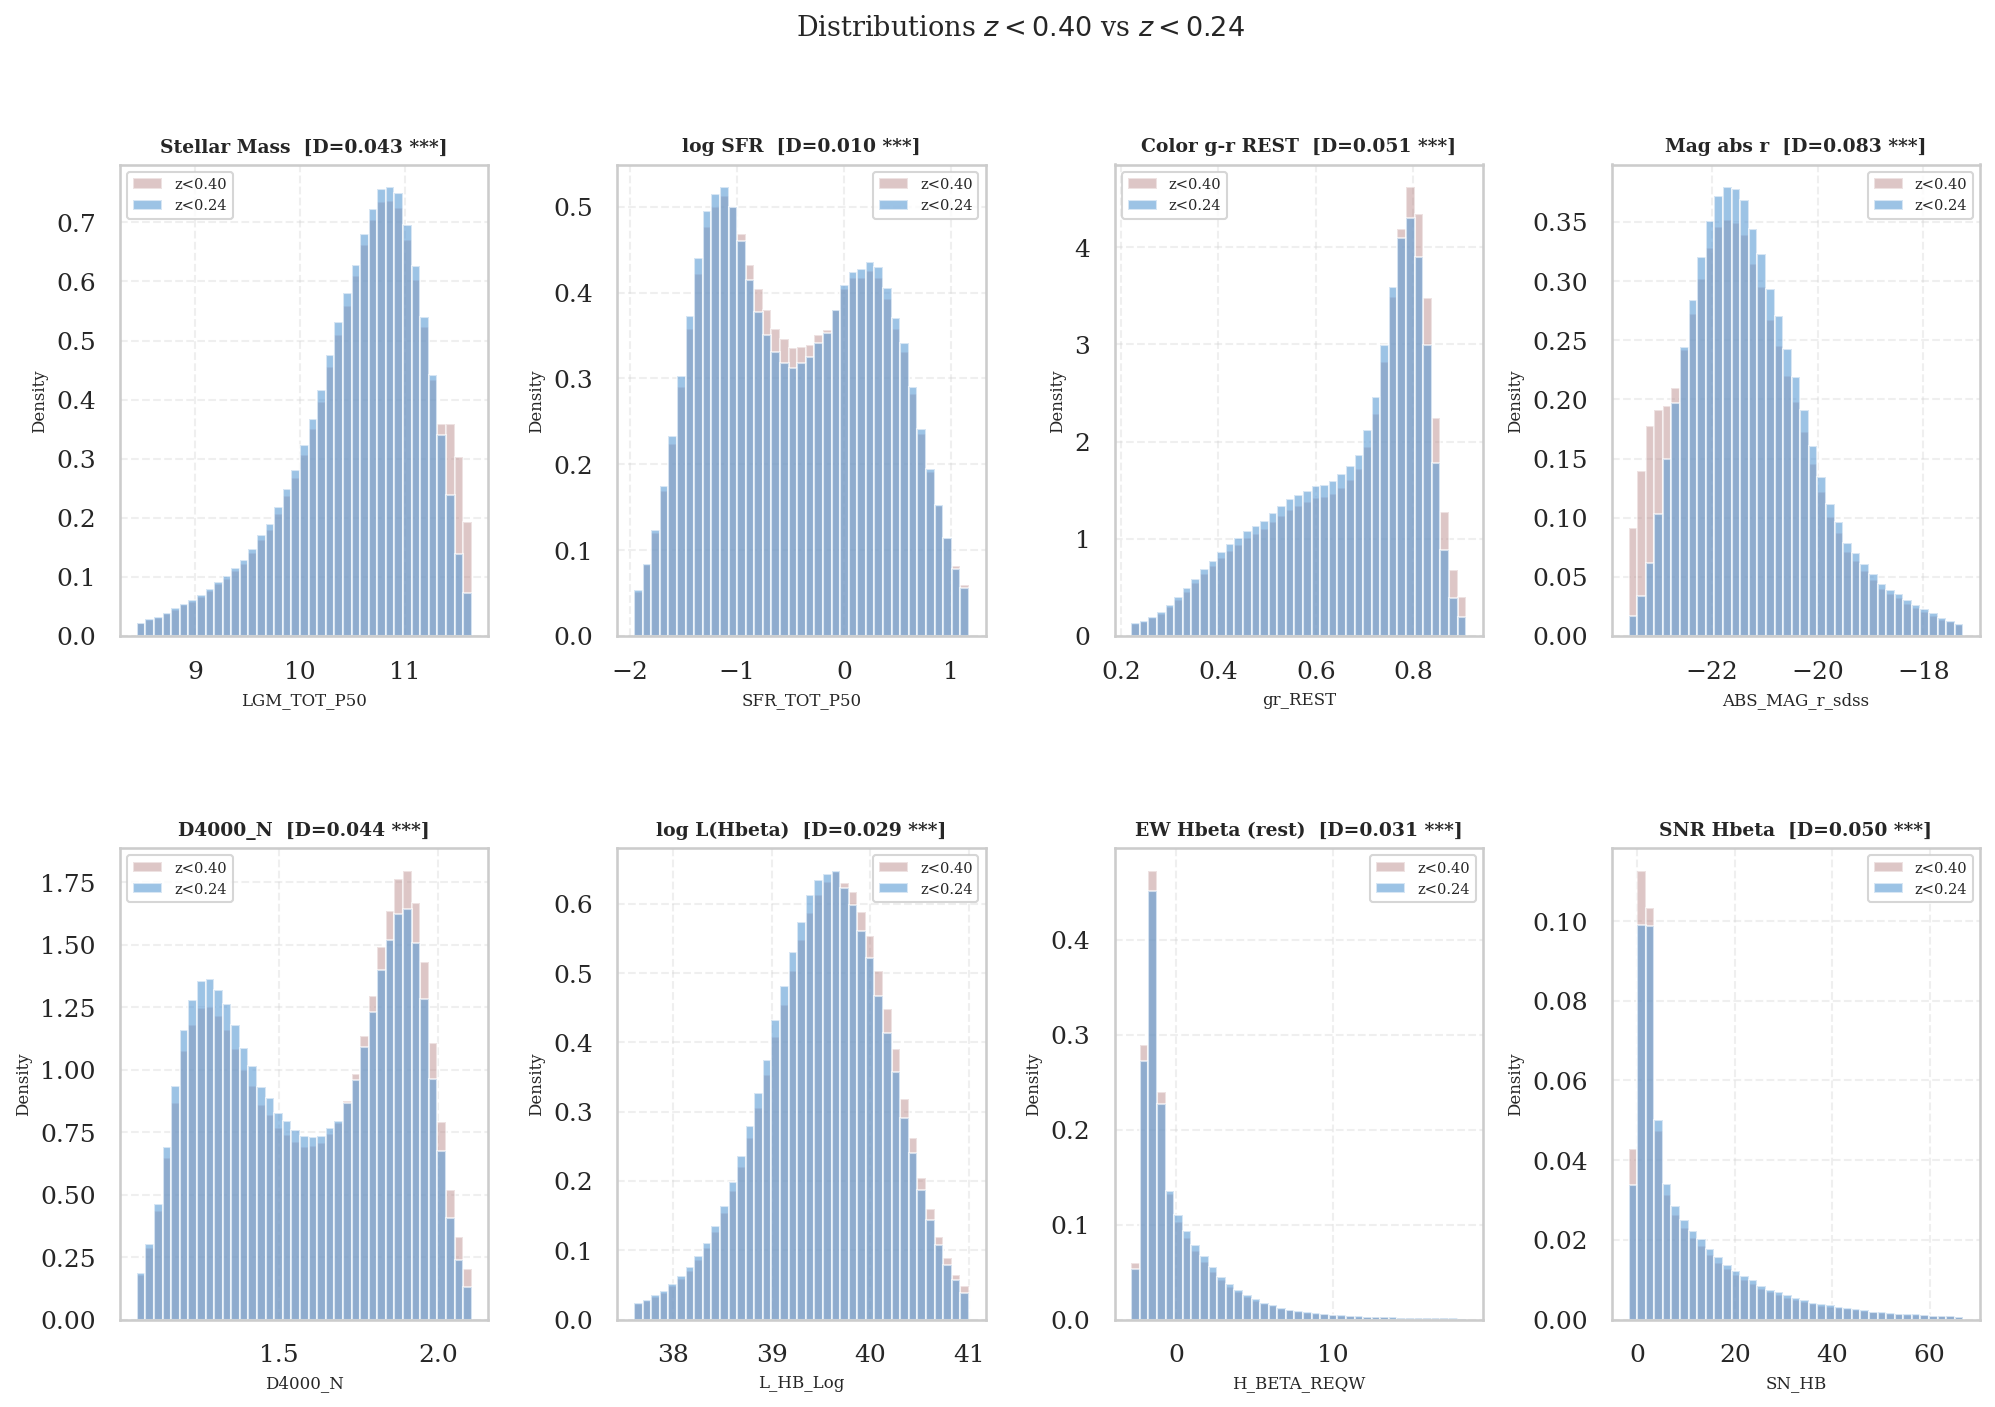

In [86]:
#  Test KS sobre propiedades físicas 
propiedades_z = {
    'Stellar Mass'    : 'LGM_TOT_P50',
    'log SFR'         : 'SFR_TOT_P50',
    'Color g-r REST'  : 'gr_REST',
    'Mag abs r'       : 'ABS_MAG_r_sdss',
    'D4000_N'         : 'D4000_N',
    'log L(Hbeta)'    : 'L_HB_Log',
    'EW Hbeta (rest)' : 'H_BETA_REQW',
    'SNR Hbeta'       : 'SN_HB',
}

# Definición de muestras
cols_needed = ['Z'] + list(propiedades_z.values())

# Vistas ligeras — sin .copy(), sin duplicar memoria
z_far   = df.loc[df['Z'] < 0.40, cols_needed]
z_close = df.loc[df['Z'] < 0.24, cols_needed]

print(f"z < 0.40 : {len(z_far):,} galaxias")
print(f"z < 0.24 : {len(z_close):,} galaxias")

print(f"Fracción retenida: {len(z_close)/len(z_far):.1%}")
print(f"Galaxias perdidas: {len(z_far)-len(z_close):,}")

print(f"\n{'Propiedad':<20} {'N(z<0.40)':>10} {'N(z<0.24)':>10} "
      f"{'D stat':>8} {'p-valor':>10} {'Δmediana':>10} {'Efecto':>12}")
print("─" * 88)

resultados_z = []
for nombre, col in propiedades_z.items():
    a = z_far[col].replace(-9999, np.nan).dropna()
    b = z_close[col].replace(-9999, np.nan).dropna()
    if len(a) < 10 or len(b) < 10:
        continue
    ks_s, ks_p = stats.ks_2samp(a, b)
    delta_med  = np.median(b) - np.median(a)
    efecto     = "despreciable" if ks_s < 0.05 else ("moderado" if ks_s < 0.10 else "notable")
    sig        = '***' if ks_p < 0.001 else ('**' if ks_p < 0.01 else ('*' if ks_p < 0.05 else ''))
    print(f"{nombre:<20} {len(a):>10,} {len(b):>10,} "
          f"{ks_s:>8.4f} {ks_p:>10.2e} {delta_med:>10.4f}  {efecto:<12} {sig}")
    resultados_z.append({'nombre': nombre, 'col': col,
                          'ks_s': ks_s, 'ks_p': ks_p, 'delta_med': delta_med})

# Completeness por masa y SNR
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
for ax, col, label in zip(axes,
                           ['LGM_TOT_P50', 'SN_HB'],
                           ['log(M*/Msun)', 'SNR H-beta']):
    da = z_far[col].replace(-9999, np.nan).dropna()
    db = z_close[col].replace(-9999, np.nan).dropna()
    bins = np.linspace(da.quantile(0.01), da.quantile(0.99), 15)
    n_far,   _ = np.histogram(da, bins=bins)
    n_close, _ = np.histogram(db, bins=bins)
    comp = np.where(n_far > 0, n_close / n_far, np.nan)
    mids = 0.5 * (bins[:-1] + bins[1:])
    ax.bar(mids, comp, width=np.diff(bins)*0.85, color=TFM_COLORS['snr_estricto'], alpha=0.7)
    ax.axhline(1.0, color='k', lw=1, ls='--')
    ax.axhline(len(z_close)/len(z_far), color='red', lw=1.5, ls=':',
               label='global completeness')
    ax.set_xlabel(label); ax.set_ylabel('Completeness (z<0.24 / z<0.40)')
    ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=0.3)
plt.suptitle('Completeness of $z < 0.24$ cut relative to $z < 0.40$', fontsize=12)
plt.tight_layout()
plt.show()

# Distribuciones superpuestas
fig = plt.figure(figsize=(16, 10))
gs  = gridspec.GridSpec(2, 4, hspace=0.45, wspace=0.35)
for idx, r in enumerate(resultados_z):
    ax = fig.add_subplot(gs[idx // 4, idx % 4])
    a  = z_far[r['col']].replace(-9999, np.nan).dropna()
    b  = z_close[r['col']].replace(-9999, np.nan).dropna()
    lo, hi = np.percentile(pd.concat([a, b]), [1, 99])
    bins = np.linspace(lo, hi, 40)
    ax.hist(a, bins=bins, density=True, alpha=0.5, color=TFM_COLORS['snr_dudoso'],      label='z<0.40')
    ax.hist(b, bins=bins, density=True, alpha=0.6, color=TFM_COLORS['snr_estricto'], label='z<0.24')
    sig = '***' if r['ks_p'] < 0.001 else ('**' if r['ks_p'] < 0.01 else
          ('*' if r['ks_p'] < 0.05 else 'n.s.'))
    ax.set_title(f"{r['nombre']}  [D={r['ks_s']:.3f} {sig}]", fontsize=9)
    ax.set_xlabel(r['col'], fontsize=8)
    ax.set_ylabel('Density', fontsize=8)
    ax.legend(fontsize=7)
plt.suptitle('Distributions $z<0.40$ vs $z<0.24$', fontsize=13)
plt.tight_layout()
plt.show()

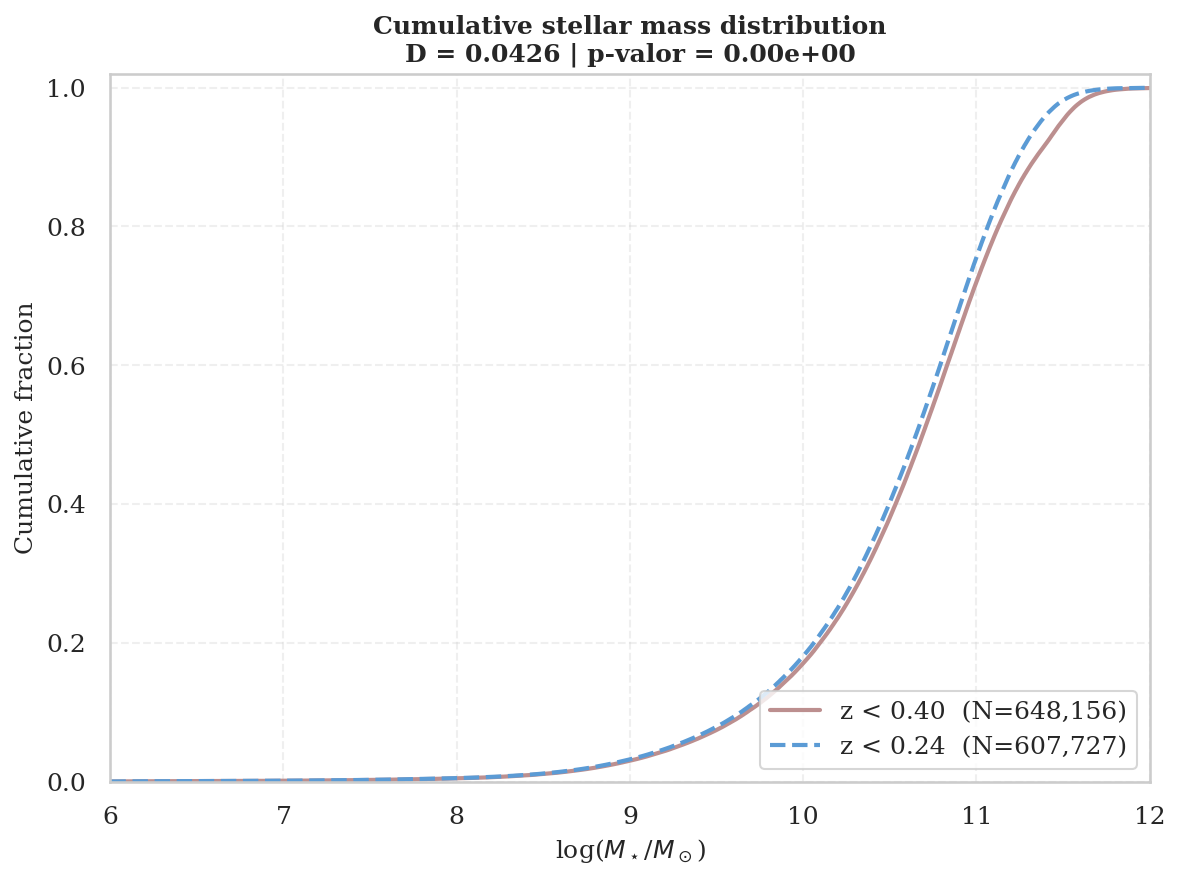

Test KS — masa estelar z<0.40 vs z<0.24:
  D = 0.0426 | p-valor = 0.00e+00 | Efecto: despreciable
  El catálogo ya era muy local; el corte no introduce sesgo adicional significativo.


In [87]:
# CDF de masa: la comparación más directa
mask_valid_mass = (z_far['LGM_TOT_P50'] > 5.0)
data_far_mass   = z_far.loc[mask_valid_mass, 'LGM_TOT_P50'].dropna()
data_close_mass = z_close[z_close['LGM_TOT_P50'] > 5.0]['LGM_TOT_P50'].dropna()

stat, p_val = stats.ks_2samp(data_far_mass, data_close_mass)

fig, ax = plt.subplots(figsize=TFM_FIG['simple'])
plot_ecdf(ax, data_far_mass,   label=f"z < 0.40  (N={len(data_far_mass):,})",
          color=TFM_COLORS['snr_dudoso'],   lw=2)
plot_ecdf(ax, data_close_mass, label=f"z < 0.24  (N={len(data_close_mass):,})",
          color=TFM_COLORS['snr_estricto'], lw=2, ls='--')

ax.set_title(f"Cumulative stellar mass distribution\n"
             f"D = {stat:.4f} | p-valor = {p_val:.2e}", fontsize=12)
ax.set_xlabel(r"log($M_\star$/$M_\odot$)", fontsize=12)
ax.set_ylabel("Cumulative fraction", fontsize=12)
ax.set_xlim(6, 12)
ax.set_ylim(0, 1.02)
ax.legend(loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

efecto = "despreciable" if stat < 0.05 else ("moderado" if stat < 0.10 else "notable")
print(f"Test KS — masa estelar z<0.40 vs z<0.24:")
print(f"  D = {stat:.4f} | p-valor = {p_val:.2e} | Efecto: {efecto}")
if stat > 0.05:
    print("  El corte en redshift modifica la distribución de masa. Es necesario y justificado.")
else:
    print("  El catálogo ya era muy local; el corte no introduce sesgo adicional significativo.")

## 9. Cortes de la muestra

Con los test Kolmogorov-Smirnov se demuestra que podemos reducir la muestra a S/N>5 y redshift<0.24 sin que las poblaciones sean significativamente diferentes.

Se añade una masa de corte de $10^5 M_{\odot}$

In [88]:
print("APLICANDO CRITERIOS DE SELECCIÓN")

# Basado en los tests anteriores, se procede a seleccionar
# la muestra de ALTA CALIDAD (S/N > 5) para asegurar la fiabilidad física,
# asumiendo los pequeños sesgos detectados.

n_inicial = len(df)

# Se aplica filtro: S/N > 5  Y  Masa Física (> 5)
df = df[(df['SN_HB'] > 5) & (df['LGM_TOT_P50'] > 5)].reset_index(drop=True)

n_final = len(df)
eliminadas = n_inicial - n_final

print(f"Galaxias Iniciales: {n_inicial}")
print(f"Galaxias Tras Filtro S/N>5: {n_final}")
print(f"-> Se han eliminado {eliminadas} objetos.")
print("-" * 40)
print("El DataFrame 'df' está ahora limpio")

APLICANDO CRITERIOS DE SELECCIÓN
Galaxias Iniciales: 712572
Galaxias Tras Filtro S/N>5: 318471
-> Se han eliminado 394101 objetos.
----------------------------------------
El DataFrame 'df' está ahora limpio


In [89]:
# Se corta en z<0.24
print(f"\n[DECISIÓN] Aplicando corte estándar z < 0.24 y z > 0.001")
df = df[(df['Z'] > 0.001) & (df['Z'] < 0.24)].reset_index(drop=True)

print(f"\nMUESTRA FINAL PARA ANÁLISIS FÍSICO: {len(df)} galaxias")


[DECISIÓN] Aplicando corte estándar z < 0.24 y z > 0.001

MUESTRA FINAL PARA ANÁLISIS FÍSICO: 312474 galaxias


Se guarda esta muestra ya procesada para operar sobre ella directamente.

In [90]:
# CHECKPOINT (PICKLE)
# Se usa .pkl en lugar de .csv para guardar
# DATA_FOLDER es la variable que se define al principio (datos/)
checkpoint_filename = "SDSS_Master_FINAL_CHECKPOINT_v3.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

print(f"Intentando guardar checkpoint rápido en: {checkpoint_filename}...")

try:
    # to_pickle vuelca la memoria al disco 
    df.to_pickle(checkpoint_path)
    
    file_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"Guardado")
    print(f"Tamaño: {file_size_mb:.2f} MB")
except Exception as e:
    print(f"Error: {e}")

Intentando guardar checkpoint rápido en: SDSS_Master_FINAL_CHECKPOINT_v3.pkl...
Guardado
Tamaño: 915.18 MB


```
# CHECKPOINT (PICKLE)
# Se usa .pkl en lugar de .csv para guardar
# DATA_FOLDER es la variable que se define al principio (datos/)
checkpoint_filename = "SDSS_Master_FINAL_CHECKPOINT.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

print(f"Intentando guardar checkpoint rápido en: {checkpoint_filename}...")

try:
    # to_pickle vuelca la memoria al disco 
    df.to_pickle(checkpoint_path)
    
    file_size_mb = os.path.getsize(checkpoint_path) / (1024 * 1024)
    print(f"Guardado")
    print(f"Tamaño: {file_size_mb:.2f} MB")
except Exception as e:
    print(f"Error: {e}")
```

Para volver a cargarlo: 

```
checkpoint_filename = "SDSS_Master_FINAL_CHECKPOINT.pkl"
checkpoint_path = os.path.join(DATA_FOLDER, checkpoint_filename)

if os.path.exists(checkpoint_path):
    print("Cargando desde Pickle...")
    df = pd.read_pickle(checkpoint_path)
    print(f"-> Cargadas {len(df)} galaxias.")
else:
    print("No existe el checkpoint.")
```